# ER Diagram

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import pyqtgraph
print(pyqtgraph.__file__)
import neuroanalysis
print(neuroanalysis.__file__)
import neuroanalysis.util
import aisynphys
import aisynphys.database
print(aisynphys.__file__)

from IPython.display import display, Markdown

c:\Users\Silje\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\Silje\neuroanalysis\neuroanalysis\__init__.py
C:\Users\Silje\aisynphys\aisynphys\__init__.py


# Set up DB connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [94]:
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access
from pathlib import Path

# Define cache directory
CACHE_PATH = Path("data/aisynphys/cache").resolve()

# Create a cache directory if it does not exist
CACHE_PATH.mkdir(parents=True, exist_ok=True)

# Tell AISynPhys to use this cache
aisynphys.config.cache_path = CACHE_PATH
# SynphysDatabase.set_cache_path(CACHE_PATH)


# Make cache
DATA_ROOT = Path("data/aisynphys/cache")

# Inspect available database versions
SynphysDatabase.list_versions()  # List all available versions

# Load small database -- Uncomment to load
# DB_VERSION = 'synphys_r2.1_medium.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

# DB_VERSION = 'synphys_r2.1_full.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

[{'db_file': 'synphys_r1.0_2019-08-29_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_2019-08-29_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_2019-08-29_full.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_full.sqlite',
  'schema_

**Medium**

In [95]:
# Get file path and ensure it exist
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # database

assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [ ]:
# Get file path and ensure it exist
# DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_full.sqlite').resolve()  # database

# assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [96]:
# Create SQLite connection to SQLite database

# Because SQRT does not exist unless we do this

import sqlite3, math, pandas as pd


con = sqlite3.connect(DB_PATH)  # Create a connection object that "connects to the database"
con.create_function("SQRT", 1, math.sqrt)   # now SQLite understands SQRT()
cur = con.cursor()  # database cursor

In [40]:
# If need to close

cur.close()
con.close()

Ta med:

* Neuron gain (low, medium, high). Gain = slope of F/I curve? Knyttet til nevron ID
* Heterogeneity --> One network naturally is

https://neuronaldynamics.epfl.ch/online/Ch13.S6.html

https://neuronaldynamics.epfl.ch/online/Ch12.S4.html 




# Table overview

In [5]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


In [59]:
query = """
            SELECT fi_slope FROM intrinsic
            WHERE fi_slope IS NOT NULL
            ORDER BY fi_slope DESC
            ;
        """

df = pd.read_sql_query(query, con)

df

,fi_slope
0,3.894356e-11
1,3.199994e-11
2,5.871778e-12
3,5.325688e-12
4,5.300000e-12
...,...
4614,-1.073825e-12
4615,-1.267327e-12
4616,-1.350000e-12
4617,-1.199993e-11


In [ ]:
slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

print(slope_vals[0])

(3.8943561546762944e-11, -3.20000305176071e-11, 3.5902876328371054e-13)


In [184]:
query = """
            SELECT DISTINCT(cre_type) FROM cell
        """

df = pd.read_sql_query(query, con)

df

,cre_type
0,chat
1,cux2
2,fam84b
3,nr5a1
4,"nr5a1,pvalb"
5,ntsr1
6,pvalb
7,"pvalb,sim1"
8,"pvalb,sst"
9,rbp4



* VisP: Primary Visual Cortex
* ALM: Anterior Lateral Motor Cortex
* TCx: Temporal Cortex
* FCx: Frontal Cortex
* None
  (empty):
* PCx: Piriform Cortex
* TEa: Temporal Association Area
* ACC: Anterior Cingulate Cortex
* OCx: Occipital Cortex




# Formatting for figures

In [97]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 100,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# To be given value
slope = ['small', 'medium', 'high']
# slope_reversed = list(reversed(slope))

# Make colors once
color_map_vrest = make_color_map(slope, plt.cm.Reds)  # Reds for vrest
color_map_greens = make_color_map(slope, plt.cm.Greens)


# Queries 

In [ ]:
# Here I just show that there is only one PSP amplitude associated with a synapse


query = """ 
SELECT
    pair_id,
    COUNT(*) AS n_synapses
FROM synapse
GROUP BY pair_id
HAVING COUNT(*) > 1
ORDER BY n_synapses DESC;
"""

df = pd.read_sql_query(query, con)

df

,pair_id,n_synapses


In [98]:
# Divide fi slope into low, medium, high
# Parameterized so that we dont have to change the query each time


query = """ 

SELECT
    p.experiment_id,
    p.pre_cell_id,
    p.post_cell_id,
    p.has_synapse,
    pre.cell_class  AS pre_cell_class,
    post.cell_class AS post_cell_class,
    i_pre.fi_slope  AS fi_slope_pre,   -- presynaptic fI slope
    i_post.fi_slope AS fi_slope_post,  -- postsynaptic fI slope
    CASE
        WHEN p.has_synapse = 1 THEN syn.psp_amplitude
        ELSE NULL                     -- to keep entries where there was not a synapse
    END AS psp_amplitude
FROM pair AS p
JOIN cell       AS pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
JOIN cell       AS post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
                         AND i_pre.fi_slope IS NOT NULL
JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
                         AND i_post.fi_slope IS NOT NULL
LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
JOIN experiment AS e     ON e.id = p.experiment_id
JOIN slice      AS s     ON e.slice_id = s.id
WHERE
    s.species = 'mouse'
    AND p.has_synapse IS NOT NULL;   -- only defined synapses


        """

main = pd.read_sql_query(query, con)
df = main.copy()

df.to_csv('preprocessed_data.csv', index=False)

df


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,NaN
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,NaN
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,0.000379


In [8]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
df


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,NaN
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,NaN
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,0.000379


Remove those entries where a cell had negative f-I slope?

Negative f-I slope

In [ ]:
import pandas as pd
df = pd.read_csv("negative_fi_slope.csv")
df

,experiment_id,synapse_id,pre_cell_id,post_cell_id,has_synapse,psp_amplitude,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post
0,699,2944,4698,4700,1,0.000038,ex,in,1.158730e-13,-1.269841e-14
1,699,2947,4703,4700,1,NaN,ex,in,8.730159e-14,-1.269841e-14
2,729,166,4848,4847,1,-0.000079,in,ex,8.388078e-14,-6.942506e-15
3,731,148,4860,4858,1,NaN,in,ex,9.062500e-13,-8.975610e-14
4,772,886,5065,5064,1,NaN,in,in,6.177606e-14,-2.193050e-13
5,772,888,5067,5064,1,0.000033,ex,in,1.281853e-13,-2.193050e-13
6,779,966,5096,5101,1,-0.000015,in,ex,1.250000e-14,-3.999999e-14
7,793,1275,5166,5172,1,NaN,in,in,1.314286e-13,-1.355932e-14
8,793,1302,5169,5172,1,-0.000589,in,in,6.499999e-13,-1.355932e-14
9,793,1313,5171,5172,1,-0.000420,in,in,4.457142e-13,-1.355932e-14


# Analysis of PSP Ampltide vs. f-I slope 

In [ ]:
figure_folder = 'figures_analysis'

In [36]:
#Various prints


import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()

print(f"There was {dfA['experiment_id'].nunique()} unique experiments")  # unique experiments
pre_cells  = dfA["pre_cell_id"].unique()
post_cells = dfA["post_cell_id"].unique()
all_cells = np.unique(np.concatenate((pre_cells, post_cells)))
print(f"There was {dfA['pre_cell_id'].nunique()} pre cells")
print(f"There was {dfA['post_cell_id'].nunique()} post cells")
print(f"There was {len(all_cells)} cells involved")


print("--- Counts of the different f-I categories when we use unique cells ---")
unique_cells_pre = dfA.drop_duplicates(subset=["pre_cell_id"], keep="first").copy()  # keeps first occurrence of a cell
unique_cells_post = dfA.drop_duplicates(subset=["post_cell_id"], keep="first").copy()  # keeps first occurrence of a cell


# print(unique_cells_post['post_fi_category'].value_counts())
# print(unique_cells_post['post_fi_category_pct'].value_counts())
# print(unique_cells_post['post_fi_category_quart'].value_counts())

print("-- Negatives --")
df_copy = df[df["fi_slope_post"]>=0]
df_noneg = df_copy[df_copy["fi_slope_pre"]>=0]

# ----  All rows that were labelled “neg” for the PRE cell ----
# ---- All rows that were labelled “neg” for the POST cell ----
neg_post = unique_cells_post[unique_cells_post['fi_slope_post'] == 'neg']
print("How many negative‑post rows:", len(neg_post))


print(f'Min value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].min()}')
print(f'Max value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].max()}')
print(f'Average value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].mean()}')
print(f'Min value of PSP amplitude: {df_noneg["psp_amplitude"].min()}')
print(f'Average value of PSP amplitude: {df_noneg["psp_amplitude"].mean()}')
print(f'Max value of PSP amplitude: {df_noneg["psp_amplitude"].max()}')


There was 878 unique experiments
There was 2871 pre cells
There was 2871 post cells
There was 2873 cells involved
--- Counts of the different f-I categories when we use unique cells ---
-- Negatives --
How many negative‑post rows: 0
Min value of f-I slope of presynaptic cell: 0.0
Max value of f-I slope of presynaptic cell: 5.871777868573806e-12
Average value of f-I slope of presynaptic cell: 4.92921555099356e-13
Min value of PSP amplitude: -0.0028355749708005
Average value of PSP amplitude: -0.0001810869029754401
Max value of PSP amplitude: 0.0049118499067469


We want to investigate distribution of weights for which the postsynaptic neurons belong to each f-I category. We let experiments count as 'seeds', and take mean and standard deviation of of PSPamplitude across experiments per f-I slope category of postsynaptic cell, where presynaptic cell can be either.

In [20]:

# # DF to CSV
# df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# dfA = df.copy()
# dfA_nonan = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude


# # Categorization
# measuretype = ""
# measuretype = "_pct"
# measuretype = "_quart"
# cats = ["small", "medium", "high"]


# experiment_ids = dfA_nonan["experiment_id"].unique()  # Get unique experiment ids
# n_experiments = len(experiment_ids)  # how many experiments

# rows = []

# excluded = 0 # count how many was excluded

# for i, exp in enumerate(experiment_ids):  # Loop through experiments
#     for cat in cats:
#         # Take out current category within current experiment
#         df_filtered = dfA_nonan[(dfA_nonan['experiment_id']==exp) & (dfA_nonan[f"post_fi_category{measuretype}"]==cat)]

#         if len(df_filtered) == 0:
#             excluded += 1
#             continue  # Do not include empty dataframe

#         elif len(df_filtered) > 0:
#             psp_amplitudes = df_filtered["psp_amplitude"].to_numpy()  # Get the psp amplitude associated with it. There might be more than one synapse within an experiment, so the dataframe below needs one record per PSP amplitude

#             # Get population size
#             pre_cells  = df_filtered["pre_cell_id"].unique()
#             post_cells = df_filtered["post_cell_id"].unique()
#             all_cells = np.unique(np.concatenate((pre_cells, post_cells)))
#             num_pre_cells  = len(pre_cells)
#             num_post_cells = len(post_cells)
#             pop_size       = len(all_cells)



#             for psp in psp_amplitudes:  # One row per combination with the PSP amplitudes recorded
#                 row = [exp, cat, psp, pop_size, num_pre_cells, num_post_cells]  
#                 rows.append(row)







# cats = ["small", "medium", "high"]


# columns = ["experiment_id", "post_cell_fi_category", "psp_amplitude", "population_size", "num_pre_cells", "num_post_cells"]
# dfStat = pd.DataFrame(rows, columns=columns)



# df = dfStat.copy()
 
# # df.groupby("experiment_id").size().reset_index(name="count")
# print(f"Number of experiments in total: {len(df['experiment_id'].unique())}")
 
# print(f'Max population size: {df["population_size"].max()}')
# print(f'Min population size: {df["population_size"].min()}')
# print(f'Average population size: {df["population_size"].mean()}')
# print(f'Number of unique experiments: {len(df["experiment_id"].unique())}')
 
# print("===== Across categories of f-I slope =====")
 
 
# cats = ["small", "medium", "high"]
 
 
# for cat in cats:
#     print(f" --- {cat.upper()} f-I slope ---")
#     df_filtered = df[df["post_cell_fi_category"]==cat]
 
#     print(f'Max population size: {df_filtered["population_size"].max()}')
#     print(f'Min population size: {df_filtered["population_size"].min()}')
#     print(f'Average population size: {df_filtered["population_size"].mean()}')
#     print(f'Standard deviation: {df_filtered["population_size"].std()}')
#     print(f'Number of unique experiments: {len(df_filtered["experiment_id"].unique())}')

# print(excluded)
# df

Plot just PSP Amplitude vs. f-I slope, no categorization   

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\323795527.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


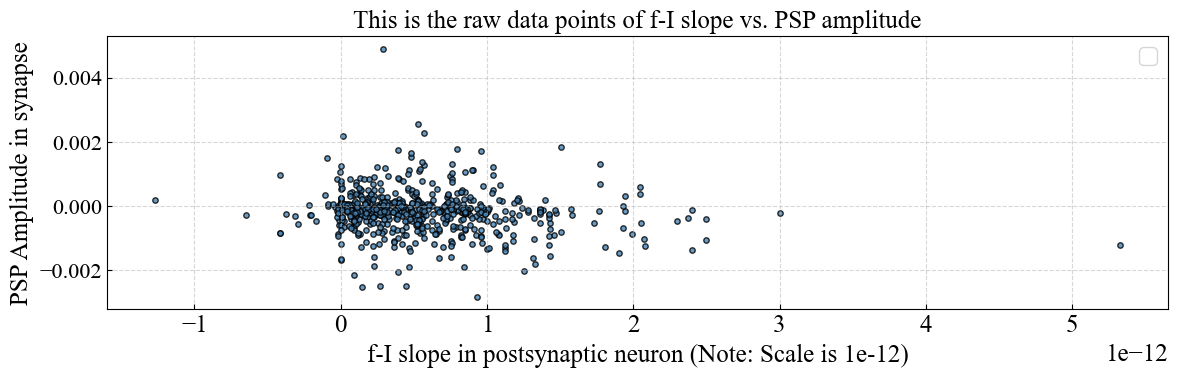

In [102]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")

dfA = df.copy()

dfA_nonan = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

import numpy as np

# View cutoffs


df_synapses = dfA_nonan[dfA_nonan["has_synapse"]==1]

df_synapses

# print(f"Number of unique synapses: {len(df_synapses['synapse_id'].unique())}")

df_xy = df_synapses[["fi_slope_post", "psp_amplitude"]]

plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", s=15, alpha=0.8, edgecolor="k")
plt.title("This is the raw data points of f-I slope vs. PSP amplitude")
plt.xlabel("f-I slope in postsynaptic neuron (Note: Scale is 1e-12)")
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



In [48]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,NaN
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,NaN
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,0.000379


In [117]:
df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()
df_test = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude
df_test["fi_norm"] = df_test["fi_slope_post"] / 1e-12
mean_fi = df_test['fi_norm'].mean()
diff = abs(0 - mean_fi)
diff_diff = diff / 2
zero_to_one = np.arange(0, 1, diff_diff)
rest = (2, np.inf)
bins = [-np.inf, (mean_fi - diff), mean_fi, (mean_fi+diff), 2, np.inf]
bins = np.concatenate((zero_to_one, rest))
print(f"BINS: {bins}")
labels = [
    "negative",
    "small",
    "medium",
    "high",
    "very_high",
    # "extreme"
]





BINS: [0.         0.27684606 0.55369211 0.83053817 2.                inf]


C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\2353924640.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["fi_norm"] = df_test["fi_slope_post"] / 1e-12


# More bins

[1.1314518997244929e-13, 8.230065275570382e-13, 7.692308149393981e-14, 2e-13, -1.2698412698412691e-14, 5.062499930755573e-13, 6.240000309448212e-14, 4.3474285483161694e-13, -6.942505546770364e-15, 9.062499891607815e-13, -2.1930501930501898e-13, -3.999998735700493e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.3559321157208228e-14, -1.3559321157208228e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.9685041005704823e-14, 1.1851430090680786e-12, 1.399999889373778e-13, 1.8999994970251957e-12, 8.688916827967505e-13, 9.285713940055957e-13, -8.648648648648622e-14, 6.728571482132788e-13, -8.648648648648622e-14, 9.285713940055957e-13, 2.702701588109368e-14, 1.0656370656370646e-13, 5.649999656677224e-13, 5.649999656677224e-13, -2.0758367494562238e-13, 0.0, 1.0285714156539152e-13, 4.552422805491578e-13, 6.509530714398713e-13, 7.862572646808148e-13, 6.371428369119826e-13, 2.791116663303136e-13, 4.399999839419386e-13, 4.814285317972421e-13, 7.640001491699337e-13, 2.666666666666668e-13, 1

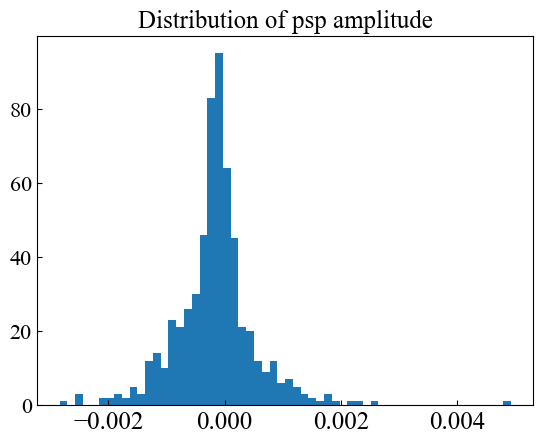

Possible range: [np.float64(0.0), np.float64(0.553692114841065), np.float64(1.10738422968213), 2, inf]
[0.1131451899724493, 0.8230065275570382, 0.07692308149393981, 0.2, -0.012698412698412691, 0.5062499930755573, 0.06240000309448212, 0.43474285483161695, -0.006942505546770364, 0.9062499891607815, -0.219305019305019, -0.03999998735700493, 0.2428571353315485, 0.445714243591726, -0.013559321157208228, -0.013559321157208228, 0.2428571353315485, 0.445714243591726, -0.019685041005704822, 1.1851430090680786, 0.1399999889373778, 1.8999994970251957, 0.8688916827967506, 0.9285713940055957, -0.08648648648648623, 0.6728571482132788, -0.08648648648648623, 0.9285713940055957, 0.027027015881093682, 0.10656370656370646, 0.5649999656677224, 0.5649999656677224, -0.20758367494562238, 0.0, 0.10285714156539152, 0.4552422805491578, 0.6509530714398714, 0.7862572646808148, 0.6371428369119826, 0.2791116663303136, 0.4399999839419386, 0.48142853179724215, 0.7640001491699338, 0.2666666666666668, 1.313332901679266

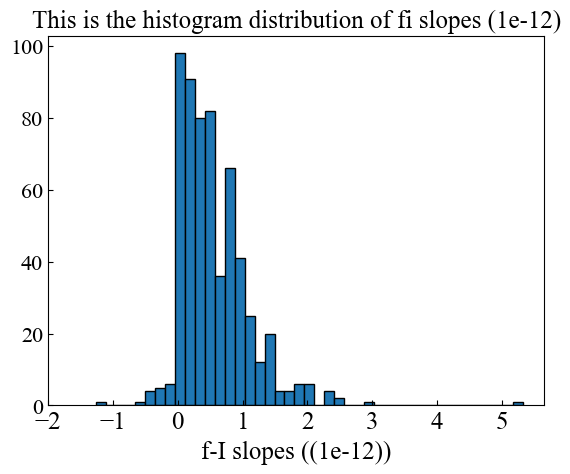

BINS: [      -inf 0.         0.33333333 0.66666667 1.         2.
        inf]


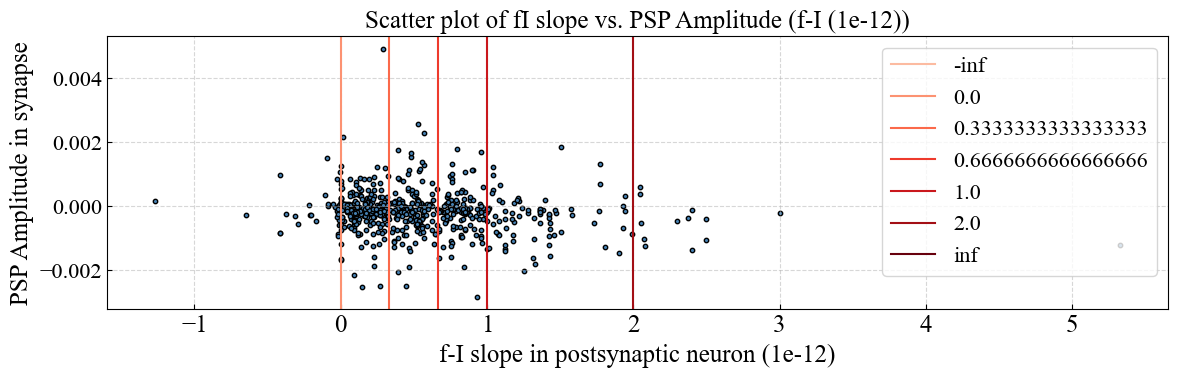

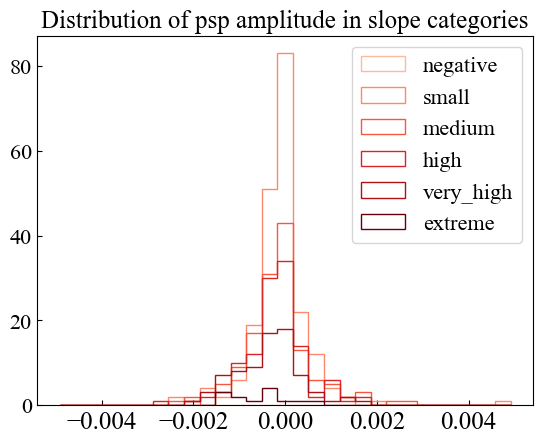

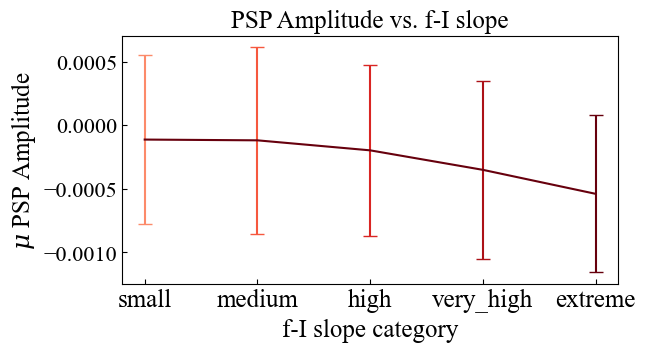

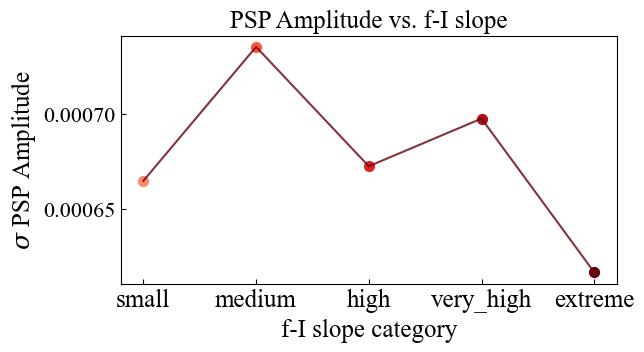

In [229]:
# Import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))


df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()
df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

# First inspection of psp amplitude and fi slope
fi_slopes = df["fi_slope_post"].tolist()
print(fi_slopes)
# print(f"Mean of f-I slope: {(df['fi_slope_post'].mean()).round(3)}")
plt.hist(df["psp_amplitude"], bins='auto')
plt.title("Distribution of psp amplitude")
plt.show()

# plt.hist(df["fi_slope_post"], bins='auto')
# plt.axvline((1*1e-12), color="black")
# plt.title("Distribution of f-I slopes")
# plt.show()


# ------------------------------------------------------------
# Because of how the distribution looked, we had to think about how to bin data
# Lots of data close to zero, more spread after. So Ive tried a smaller bin size close to zero, then wider


df_test = df.copy()


# normalize 
df_test["fi_norm"] = df_test["fi_slope_post"] / 1e-12
fi_slopes_normalized = df_test["fi_norm"].tolist()  # list of the values
mean_fi = df_test['fi_norm'].mean()
diff = abs(0 - mean_fi)
range = [(mean_fi - diff), mean_fi, (mean_fi+diff), 2, np.inf]
print(f"Possible range: {range}")
print(fi_slopes_normalized)


plt.hist(df_test["fi_norm"], bins='auto', edgecolor='black')
plt.title("This is the histogram distribution of fi slopes (1e-12)")
plt.xticks(np.arange(-2, 6, 1))
plt.xlabel(f"f-I slopes ((1e-12))")
# plt.axvline(1, color='black')
# plt.axvline(0.3, color='black')
plt.show()


###################### Grouping ################################


# Quantiles: Might cause problems since there are way more data in a smaller portion

# df_test["category"] = pd.qcut(df_test["fi_norm"], q=5,     labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]
# )

# labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]


# df = pd.read_csv("preprocessed_data.csv")
# dfA = df.copy()
# df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude
# # keep the negative values in their own class
# pos = df.loc[df['fi_slope_post'] >= 0, 'fi_slope_post']
# quantiles = pos.quantile([0, 0.33, 0.66, 1.0]).values   # tertiles
# bins = np.concatenate(([-np.inf], quantiles[1:], [np.inf]))
# labels = ['neg', 'low', 'mid', 'high']
# df['category'] = pd.cut(df['fi_slope_post'], bins=bins, labels=labels, include_lowest=True)

# df_test = df.copy()



# ------------------------------------------------------------
# Binning: Could be better with small bins where there are many data points, and wider and wider?

# bins = [0, 0.05, 0.2, 0.5, 1, 2, np.inf]
# bins = [0, 0.25, 0.75, 1, 2, np.inf]


mean_fi = df_test['fi_norm'].mean()
# diff = abs(0 - mean_fi)
# diff_diff = diff / 2
# zero_to_one = np.arange(0, 1, diff_diff)
# rest = (2, np.inf)
# bins = [-np.inf, (mean_fi - diff), mean_fi, (mean_fi+diff), 2, np.inf]
# bins = np.concatenate((zero_to_one, rest))
# print(f"BINS: {bins}")
# labels = [
#     "negative",
#     "small",
#     "medium",
#     "high",
#     "very_high",
#     # "extreme"
# ]


# ------------------------------------------------------------
# Linearly spaced bins 
neg = -np.inf
bins1 = np.linspace(0, 1, 4)
rest = (2, np.inf)
bins = np.concatenate((bins1, rest))
bins = np.insert(bins, 0, neg)
print(f"BINS: {bins}")
labels = [
    "negative",
    "small",
    "medium",
    "high",
    "very_high",
    "extreme"
]
# ------------------------------------------------------------


# bins = [0, 0.5, 1, np.inf]
# # bins = [0, 0.05, 1, np.inf]
# labels = [
#     "small",
#     "medium",
#     "high"
# ]

# bins = [0, 0.5, 2, np.inf]
# labels = [
#     "small",
#     "medium",
#     "high"
# ]

# bins = [0, 0.05, 0.5, 1, np.inf]
# labels = [
#     "tiny",
#     "small",
#     "medium",
#     "high"
# ]


# # labels = [str(i) for i in range(3)]


df_test["category"] = pd.cut(
    df_test["fi_norm"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_test.to_csv('preprocessed_data_categorized.csv')

# df_test




df_test["category"].value_counts()


# ------------------------------------------------------------
# Plots

color_map_fi = make_color_map(labels, plt.cm.Reds)  # Color map

# Cutoff borders
df_xy = df_test[["fi_norm", "psp_amplitude"]]
# df_xy = df_test[["fi_slope_post", "psp_amplitude"]]
plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_norm"], df_xy["psp_amplitude"], color="steelblue", s=10, edgecolor="k")
# plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", s=10, edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (f-I (1e-12))")
plt.xlabel("f-I slope in postsynaptic neuron (1e-12)")

bin_plus = [(i + 1) for i in bins]
bin_colors = make_color_map(bin_plus, plt.cm.Reds)

for b, color in zip(bins, bin_colors):
    plt.axvline(b, color=bin_colors[color], label=b)

# plt.axvline(mean_fi, color='black', label="Mean of f-I slope")
# plt.xlim(-0.02, 1)
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Exclude negative

df_test = df_test[df_test["category"] != 'negative']


# Histogram across categories
all_vals = df_test["psp_amplitude"].values
max_abs = np.max(np.abs(all_vals))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 30)

fig, ax = plt.subplots(nrows=1, ncols=1)

for l in labels:
    df = df_test[df_test["category"]==l]

    ax.hist(df["psp_amplitude"], bins=bins, histtype='step', color=color_map_fi[l], label=l)
ax.set_title("Distribution of psp amplitude in slope categories")
plt.legend()
plt.show()


# First and second moment
meanvals = []
stdvals = []
semvals = []

labels = [
    # "negative",
    "small",
    "medium",
    "high",
    "very_high",
    "extreme"
]

for l in labels:
    # df_filtered = df_test[(df_test[f"category"]==l) & (df_test["has_synapse"]==1)]  # this category across experiments
    df_filtered = df_test[(df_test[f"category"]==l) & (df_test["has_synapse"]==1)]  # this category across experiments

    # Mean of PSP Amplitude across experiments for current 
    mean_psp = df_filtered["psp_amplitude"].mean()  
    meanvals.append(mean_psp)

    # Standard deviation of PSP amplitude across experiments
    std_psp = df_filtered["psp_amplitude"].std()  
    sem_psp = df_filtered["psp_amplitude"].sem()
    stdvals.append(std_psp)
    semvals.append(sem_psp)


# ------------- Mean with errorbars ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(8, 4)
    )
for l, y, yerr in zip(labels, meanvals, stdvals):
    ax.errorbar(l, y, yerr, capsize=5, color=color_map_fi[l])
    
ax.plot(labels, meanvals, color=color_map_fi[l])
ax.set_ylabel(f"$\mu$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(0.5)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# ------------- Standard deviation ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(5, 4)
    )
ax.plot(labels, stdvals, color=color_map_fi[l], alpha=0.8)
for l, y in zip(labels, stdvals):
    ax.scatter(l, y, s=50, color=color_map_fi[l])
    
ax.set_ylabel(f"$\sigma$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(0.5)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# df_test_quantile

# Fewer bins

In [219]:
neg = -np.inf
bins = np.linspace(0, 1, 3)
# rest = (2, np.inf)
# bins = np.concatenate((bins1, rest))
bins = np.insert(bins, 0, neg)
bins = np.insert(bins, len(bins), np.inf)
print(f"BINS: {bins}")
labels = [
    "negative",
    "small",
    "medium",
    "high",
    # "very_high",
    # "extreme"
]


BINS: [-inf  0.   0.5  1.   inf]


[1.1314518997244929e-13, 8.230065275570382e-13, 7.692308149393981e-14, 2e-13, -1.2698412698412691e-14, 5.062499930755573e-13, 6.240000309448212e-14, 4.3474285483161694e-13, -6.942505546770364e-15, 9.062499891607815e-13, -2.1930501930501898e-13, -3.999998735700493e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.3559321157208228e-14, -1.3559321157208228e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.9685041005704823e-14, 1.1851430090680786e-12, 1.399999889373778e-13, 1.8999994970251957e-12, 8.688916827967505e-13, 9.285713940055957e-13, -8.648648648648622e-14, 6.728571482132788e-13, -8.648648648648622e-14, 9.285713940055957e-13, 2.702701588109368e-14, 1.0656370656370646e-13, 5.649999656677224e-13, 5.649999656677224e-13, -2.0758367494562238e-13, 0.0, 1.0285714156539152e-13, 4.552422805491578e-13, 6.509530714398713e-13, 7.862572646808148e-13, 6.371428369119826e-13, 2.791116663303136e-13, 4.399999839419386e-13, 4.814285317972421e-13, 7.640001491699337e-13, 2.666666666666668e-13, 1

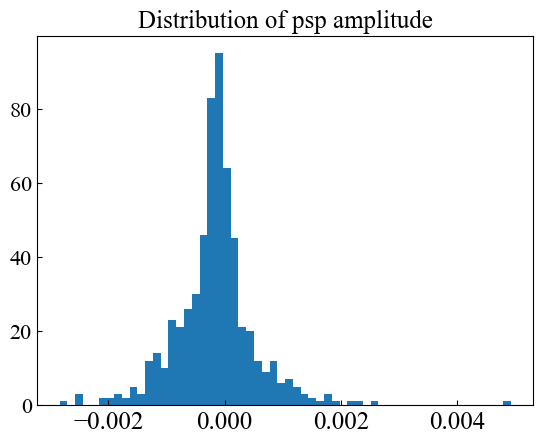

Possible range: [np.float64(0.0), np.float64(0.553692114841065), np.float64(1.10738422968213), 2, inf]
[0.1131451899724493, 0.8230065275570382, 0.07692308149393981, 0.2, -0.012698412698412691, 0.5062499930755573, 0.06240000309448212, 0.43474285483161695, -0.006942505546770364, 0.9062499891607815, -0.219305019305019, -0.03999998735700493, 0.2428571353315485, 0.445714243591726, -0.013559321157208228, -0.013559321157208228, 0.2428571353315485, 0.445714243591726, -0.019685041005704822, 1.1851430090680786, 0.1399999889373778, 1.8999994970251957, 0.8688916827967506, 0.9285713940055957, -0.08648648648648623, 0.6728571482132788, -0.08648648648648623, 0.9285713940055957, 0.027027015881093682, 0.10656370656370646, 0.5649999656677224, 0.5649999656677224, -0.20758367494562238, 0.0, 0.10285714156539152, 0.4552422805491578, 0.6509530714398714, 0.7862572646808148, 0.6371428369119826, 0.2791116663303136, 0.4399999839419386, 0.48142853179724215, 0.7640001491699338, 0.2666666666666668, 1.313332901679266

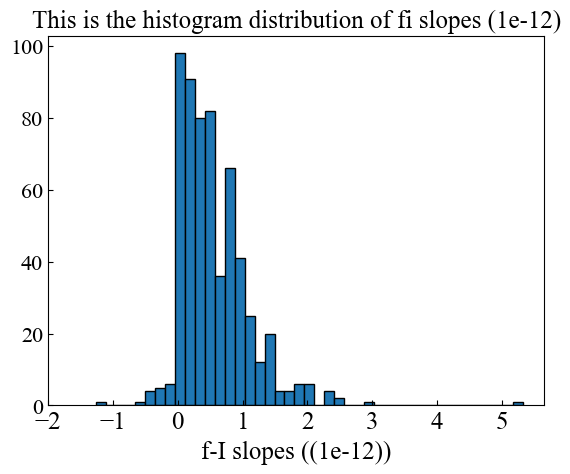

BINS: [-inf  0.   0.5  1.   inf]
Number of bins: 5. Number of labels: 4


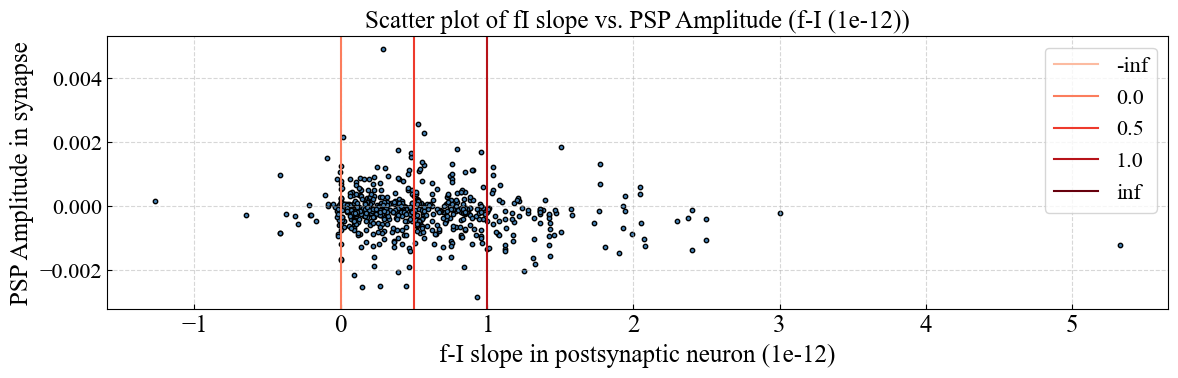

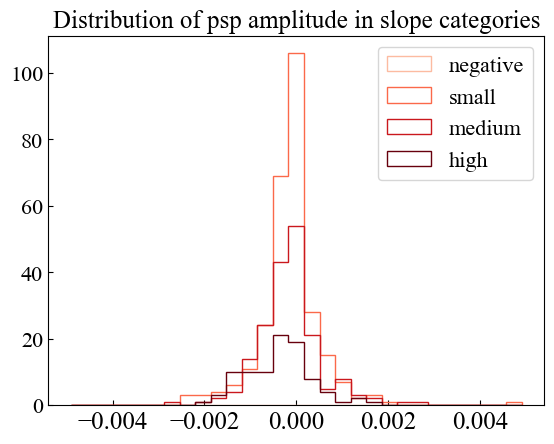

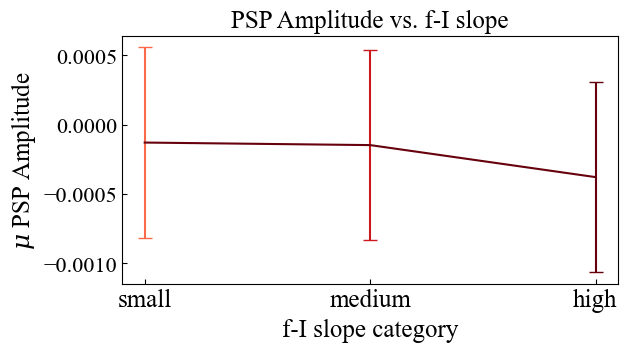

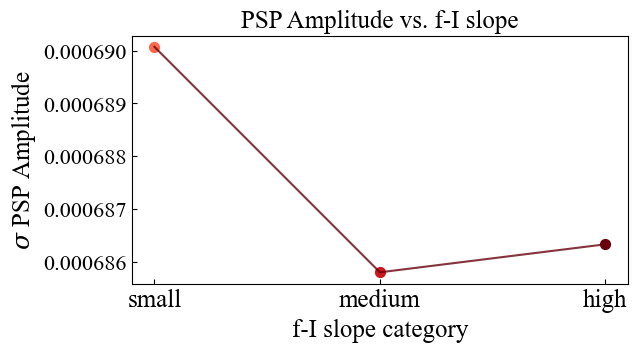

[np.float64(-0.00012930106978227134), np.float64(-0.00014758244907020525), np.float64(-0.00037853107242864125)]
[np.float64(0.0006900704193893613), np.float64(0.0006857971606259189), np.float64(0.0006863279998503332)]


In [222]:
# Import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))


df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()
df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

# First inspection of psp amplitude and fi slope
fi_slopes = df["fi_slope_post"].tolist()
print(fi_slopes)
# print(f"Mean of f-I slope: {(df['fi_slope_post'].mean()).round(3)}")
plt.hist(df["psp_amplitude"], bins='auto')
plt.title("Distribution of psp amplitude")
plt.show()

# plt.hist(df["fi_slope_post"], bins='auto')
# plt.axvline((1*1e-12), color="black")
# plt.title("Distribution of f-I slopes")
# plt.show()


# ------------------------------------------------------------
# Because of how the distribution looked, we had to think about how to bin data
# Lots of data close to zero, more spread after. So Ive tried a smaller bin size close to zero, then wider


df_test = df.copy()


# normalize 
df_test["fi_norm"] = df_test["fi_slope_post"] / 1e-12
fi_slopes_normalized = df_test["fi_norm"].tolist()  # list of the values
mean_fi = df_test['fi_norm'].mean()
diff = abs(0 - mean_fi)
range = [(mean_fi - diff), mean_fi, (mean_fi+diff), 2, np.inf]
print(f"Possible range: {range}")
print(fi_slopes_normalized)


plt.hist(df_test["fi_norm"], bins='auto', edgecolor='black')
plt.title("This is the histogram distribution of fi slopes (1e-12)")
plt.xticks(np.arange(-2, 6, 1))
plt.xlabel(f"f-I slopes ((1e-12))")
# plt.axvline(1, color='black')
# plt.axvline(0.3, color='black')
plt.show()


###################### Grouping ################################


# Quantiles: Might cause problems since there are way more data in a smaller portion

# df_test["category"] = pd.qcut(df_test["fi_norm"], q=5,     labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]
# )

# labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]


# df = pd.read_csv("preprocessed_data.csv")
# dfA = df.copy()
# df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude
# # keep the negative values in their own class
# pos = df.loc[df['fi_slope_post'] >= 0, 'fi_slope_post']
# quantiles = pos.quantile([0, 0.33, 0.66, 1.0]).values   # tertiles
# bins = np.concatenate(([-np.inf], quantiles[1:], [np.inf]))
# labels = ['neg', 'low', 'mid', 'high']
# df['category'] = pd.cut(df['fi_slope_post'], bins=bins, labels=labels, include_lowest=True)

# df_test = df.copy()



# ------------------------------------------------------------
# Binning: Could be better with small bins where there are many data points, and wider and wider?

# bins = [0, 0.05, 0.2, 0.5, 1, 2, np.inf]
# bins = [0, 0.25, 0.75, 1, 2, np.inf]


mean_fi = df_test['fi_norm'].mean()
# diff = abs(0 - mean_fi)
# diff_diff = diff / 2
# zero_to_one = np.arange(0, 1, diff_diff)
# rest = (2, np.inf)
# bins = [-np.inf, (mean_fi - diff), mean_fi, (mean_fi+diff), 2, np.inf]
# bins = np.concatenate((zero_to_one, rest))
# print(f"BINS: {bins}")
# labels = [
#     "negative",
#     "small",
#     "medium",
#     "high",
#     "very_high",
#     # "extreme"
# ]


# ------------------------------------------------------------
# Linearly spaced bins 
# neg = -np.inf
# bins1 = np.linspace(0, 1, 4)
# rest = (2, np.inf)
# bins = np.concatenate((bins1, rest))
# bins = np.insert(bins, 0, neg)
# print(f"BINS: {bins}")
# labels = [
#     "negative",
#     "small",
#     "medium",
#     "high",
#     "very_high",
#     "extreme"
# ]
# ------------------------------------------------------------
# Less groups

neg = -np.inf
bins = np.linspace(0, 1, 3)
# rest = (2, np.inf)
# bins = np.concatenate((bins1, rest))
bins = np.insert(bins, 0, neg)
bins = np.insert(bins, len(bins), np.inf)
print(f"BINS: {bins}")
labels = [
    "negative",
    "small",
    "medium",
    "high",
    # "very_high",
    # "extreme"
]


print(f"Number of bins: {len(bins)}. Number of labels: {len(labels)}")
# ------------------------------------------------------------

# bins = [0, 0.5, 1, np.inf]
# # bins = [0, 0.05, 1, np.inf]
# labels = [
#     "small",
#     "medium",
#     "high"
# ]

# bins = [0, 0.5, 2, np.inf]
# labels = [
#     "small",
#     "medium",
#     "high"
# ]

# bins = [0, 0.05, 0.5, 1, np.inf]
# labels = [
#     "tiny",
#     "small",
#     "medium",
#     "high"
# ]


# # labels = [str(i) for i in range(3)]


df_test["category"] = pd.cut(
    df_test["fi_norm"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_test.to_csv('preprocessed_data_categorized.csv')

# df_test




df_test["category"].value_counts()


# ------------------------------------------------------------
# Plots

color_map_fi = make_color_map(labels, plt.cm.Reds)  # Color map

# Cutoff borders
df_xy = df_test[["fi_norm", "psp_amplitude"]]
# df_xy = df_test[["fi_slope_post", "psp_amplitude"]]
plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_norm"], df_xy["psp_amplitude"], color="steelblue", s=10, edgecolor="k")
# plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", s=10, edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (f-I (1e-12))")
plt.xlabel("f-I slope in postsynaptic neuron (1e-12)")

bin_plus = [(i + 1) for i in bins]
bin_colors = make_color_map(bin_plus, plt.cm.Reds)

for b, color in zip(bins, bin_colors):
    plt.axvline(b, color=bin_colors[color], label=b)

# plt.axvline(mean_fi, color='black', label="Mean of f-I slope")
# plt.xlim(-0.02, 1)
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Exclude negative

df_test = df_test[df_test["category"] != 'negative']


# Histogram across categories
all_vals = df_test["psp_amplitude"].values
max_abs = np.max(np.abs(all_vals))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 30)

fig, ax = plt.subplots(nrows=1, ncols=1)

for l in labels:
    df = df_test[df_test["category"]==l]

    ax.hist(df["psp_amplitude"], bins=bins, histtype='step', color=color_map_fi[l], label=l)
ax.set_title("Distribution of psp amplitude in slope categories")
plt.legend()
plt.show()


# First and second moment
meanvals = []
stdvals = []
semvals = []

# labels = [
#     # "negative",
#     "small",
#     "medium",
#     "high",
#     "very_high",
#     "extreme"
# ]

labels = [
    # "negative",
    "small",
    "medium",
    "high",
    # "very_high",
    # "extreme"
]

for l in labels:
    # df_filtered = df_test[(df_test[f"category"]==l) & (df_test["has_synapse"]==1)]  # this category across experiments
    df_filtered = df_test[(df_test[f"category"]==l) & (df_test["has_synapse"]==1)]  # this category across experiments

    # Mean of PSP Amplitude across experiments for current 
    mean_psp = df_filtered["psp_amplitude"].mean()  
    meanvals.append(mean_psp)

    # Standard deviation of PSP amplitude across experiments
    std_psp = df_filtered["psp_amplitude"].std()  
    sem_psp = df_filtered["psp_amplitude"].sem()
    stdvals.append(std_psp)
    semvals.append(sem_psp)


# ------------- Mean with errorbars ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(8, 4)
    )
for l, y, yerr in zip(labels, meanvals, stdvals):
    ax.errorbar(l, y, yerr, capsize=5, color=color_map_fi[l])
    
ax.plot(labels, meanvals, color=color_map_fi[l])
ax.set_ylabel(f"$\mu$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(0.5)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# ------------- Standard deviation ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(5, 4)
    )
ax.plot(labels, stdvals, color=color_map_fi[l], alpha=0.8)
for l, y in zip(labels, stdvals):
    ax.scatter(l, y, s=50, color=color_map_fi[l])
    
ax.set_ylabel(f"$\sigma$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(0.5)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# df_test_quantile

print(meanvals)
print(stdvals)

In [ ]:
neg = -np.inf
bins1 = np.linspace(0, 1, 2)
rest = (2, np.inf)
bins = np.concatenate((bins1, rest))
bins = np.insert(bins, 0, neg)
print(f"BINS: {bins}")
labels = [
    "negative",
    "small",
    "medium",
    "high",
    # "very_high",
    # "extreme"
]

print(f"Number of bins: {len(bins)}. Number of labels: {len(labels)}")

In [230]:

df_test

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude,fi_norm,category
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204,0.113145,small
6,600,4140,4133,1,ex,in,1.131452e-13,8.230065e-13,0.000445,0.823007,high
27,610,4199,4201,1,ex,ex,-1.923071e-15,7.692308e-14,0.000030,0.076923,small
35,614,4225,4227,1,in,ex,6.599999e-13,2.000000e-13,-0.000168,0.200000,small
133,700,4706,4711,1,in,in,1.462500e-12,5.062500e-13,-0.000126,0.506250,medium
...,...,...,...,...,...,...,...,...,...,...,...
7951,5004,24565,24564,1,in,in,4.807973e-13,1.739197e-13,-0.001123,0.173920,small
7954,5004,24567,24564,1,in,in,7.191986e-13,1.739197e-13,-0.000221,0.173920,small
7970,5105,24778,24781,1,mixed,ex,8.018796e-13,9.525691e-14,-0.000198,0.095257,small
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314,0.066392,small


# Wilcoxon signed-rank test

In [232]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import itertools


df = df_test.copy()   # the dataframe that include categories

# keep only synapses that really exist
df = df[df['has_synapse'] == 1]

# -------------------------------------------------

# mean PSP amplitude for each (experiment, category) pair
exp_means = (
    df
    .groupby(['experiment_id', 'category'])['psp_amplitude']
    .mean()                                   # can also use .median()
    .reset_index(name='mean_psp')
)

# pivot to a wide table: rows = experiments, cols = categories
wide = exp_means.pivot(index='experiment_id',
                       columns='category',
                       values='mean_psp')
print(wide.head())

def paired_wilcoxon(wide_df, cat_a, cat_b, tail='two-sided', exact=True):
    """
    Wilcoxon signed rank test on the paired per experiment means of two categories.
    """
    # keep only experiments that have BOTH categories
    pair = wide_df[[cat_a, cat_b]].dropna()
    n = len(pair)

    if n == 0:
        return {'cat1': cat_a, 'cat2': cat_b,
                'statistic': np.nan, 'pvalue': np.nan,
                'n': 0, 'effect_size': np.nan}

    # differences (a - b)
    diff = pair[cat_a] - pair[cat_b]

    # Wilcoxon signed‑rank
    mode = 'exact' if exact else 'approx'
    W, p = stats.wilcoxon(diff,
                          zero_method='pratt',
                          alternative=tail,
                          mode=mode)

    # rank‑biserial correlation (effect size)
    n_nonzero = np.sum(diff != 0)
    r_rb = 1 - (2 * W) / (n_nonzero * (n_nonzero + 1))

    return {'cat1': cat_a, 'cat2': cat_b,
            'statistic': W,
            'pvalue': p,
            'n': n,
            'effect_size': r_rb}

categories = wide.columns.tolist()       # fi slope categories, ex: ['small','medium','high']
pairwise = []

for c1, c2 in itertools.combinations(categories, 2):
    pairwise.append(paired_wilcoxon(wide, c1, c2,
                                    tail='two-sided', exact=True))

pairwise_df = pd.DataFrame(pairwise)
print(pairwise_df[['cat1','cat2','n','statistic','pvalue','effect_size']])


print("Bonferroni correction")
m = len(pairwise_df)                     # = 3
pairwise_df['p_corr'] = np.minimum(pairwise_df['pvalue'] * m, 1.0)
print(pairwise_df[['cat1','cat2','pvalue','p_corr','effect_size']])



category       negative     small    medium      high  very_high  extreme
experiment_id                                                            
600                 NaN -0.000204       NaN  0.000445        NaN      NaN
610                 NaN  0.000030       NaN       NaN        NaN      NaN
614                 NaN -0.000168       NaN       NaN        NaN      NaN
700                 NaN       NaN -0.000126       NaN        NaN      NaN
727                 NaN  0.000030  0.000017       NaN        NaN      NaN
         cat1       cat2   n  statistic    pvalue  effect_size
0    negative      small   0        NaN       NaN          NaN
1    negative     medium   0        NaN       NaN          NaN
2    negative       high   0        NaN       NaN          NaN
3    negative  very_high   0        NaN       NaN          NaN
4    negative    extreme   0        NaN       NaN          NaN
5       small     medium  27       68.0  0.002708     0.820106
6       small       high  17       25.0  

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\887647374.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import itertools

# -------------------------------------------------

df = df_test.copy()

# keep only synapses that really exist
df = df[df['has_synapse'] == 1]

# mean PSP amplitude for each (experiment, category) pair
exp_means = (
    df
    .groupby(['experiment_id', 'category'])['psp_amplitude']
    .mean()                                   # can also use .median()
    .reset_index(name='mean_psp')
)

# pivot to a “wide” table: rows = experiments, cols = categories
wide = exp_means.pivot(index='experiment_id',
                       columns='category',
                       values='mean_psp')
print(wide.head())

def paired_wilcoxon(wide_df, cat_a, cat_b,
                    tail='two-sided', exact=True):
    """
    Wilcoxon signed rank test on the paired per experiment means of two categories.
    """
    # keep only experiments that have BOTH categories
    pair = wide_df[[cat_a, cat_b]].dropna()
    n = len(pair)

    if n == 0:
        return {'cat1': cat_a, 'cat2': cat_b,
                'statistic': np.nan, 'pvalue': np.nan,
                'n': 0, 'effect_size': np.nan}

    # differences (a - b)
    diff = pair[cat_a] - pair[cat_b]

    # Wilcoxon signed‑rank
    mode = 'exact' if exact else 'approx'
    W, p = stats.wilcoxon(diff,
                          zero_method='pratt',
                          alternative=tail,
                          mode=mode)

    # rank‑biserial correlation (effect size)
    n_nonzero = np.sum(diff != 0)
    r_rb = 1 - (2 * W) / (n_nonzero * (n_nonzero + 1))

    return {'cat1': cat_a, 'cat2': cat_b,
            'statistic': W,
            'pvalue': p,
            'n': n,
            'effect_size': r_rb}

categories = wide.columns.tolist()       # fi slope categories, ex: ['small','medium','high']
pairwise = []

for c1, c2 in itertools.combinations(categories, 2):
    pairwise.append(paired_wilcoxon(wide, c1, c2,
                                    tail='two-sided', exact=True))

pairwise_df = pd.DataFrame(pairwise)
print(pairwise_df[['cat1','cat2','n','statistic','pvalue','effect_size']])


print("Bonferroni correction")
m = len(pairwise_df)                     # = 3
pairwise_df['p_corr'] = np.minimum(pairwise_df['pvalue'] * m, 1.0)
print(pairwise_df[['cat1','cat2','pvalue','p_corr','effect_size']])



category       negative     small    medium  high
experiment_id                                    
600                 NaN -0.000204  0.000445   NaN
610                 NaN  0.000030       NaN   NaN
614                 NaN -0.000168       NaN   NaN
700                 NaN       NaN -0.000126   NaN
727                 NaN  0.000024       NaN   NaN
       cat1    cat2   n  statistic    pvalue  effect_size
0  negative   small   0        NaN       NaN          NaN
1  negative  medium   0        NaN       NaN          NaN
2  negative    high   0        NaN       NaN          NaN
3     small  medium  42      192.0  0.000842     0.787375
4     small    high  18       49.0  0.118706     0.713450
5    medium    high  20       93.0  0.674223     0.557143
Bonferroni correction
       cat1    cat2    pvalue    p_corr  effect_size
0  negative   small       NaN       NaN          NaN
1  negative  medium       NaN       NaN          NaN
2  negative    high       NaN       NaN          NaN
3     smal

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\2635000777.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df


## Adjacency matrix

These adjacency matrices marks where synapses occurred if they did. I changed to only include experiments where there was a synapse. Adjacency matrices showing if there was a synapse in an experiment and between which neurons. Change between valid_experiment (to see all) or was_synapse (to see only those with synapses)

Total experiments: 301


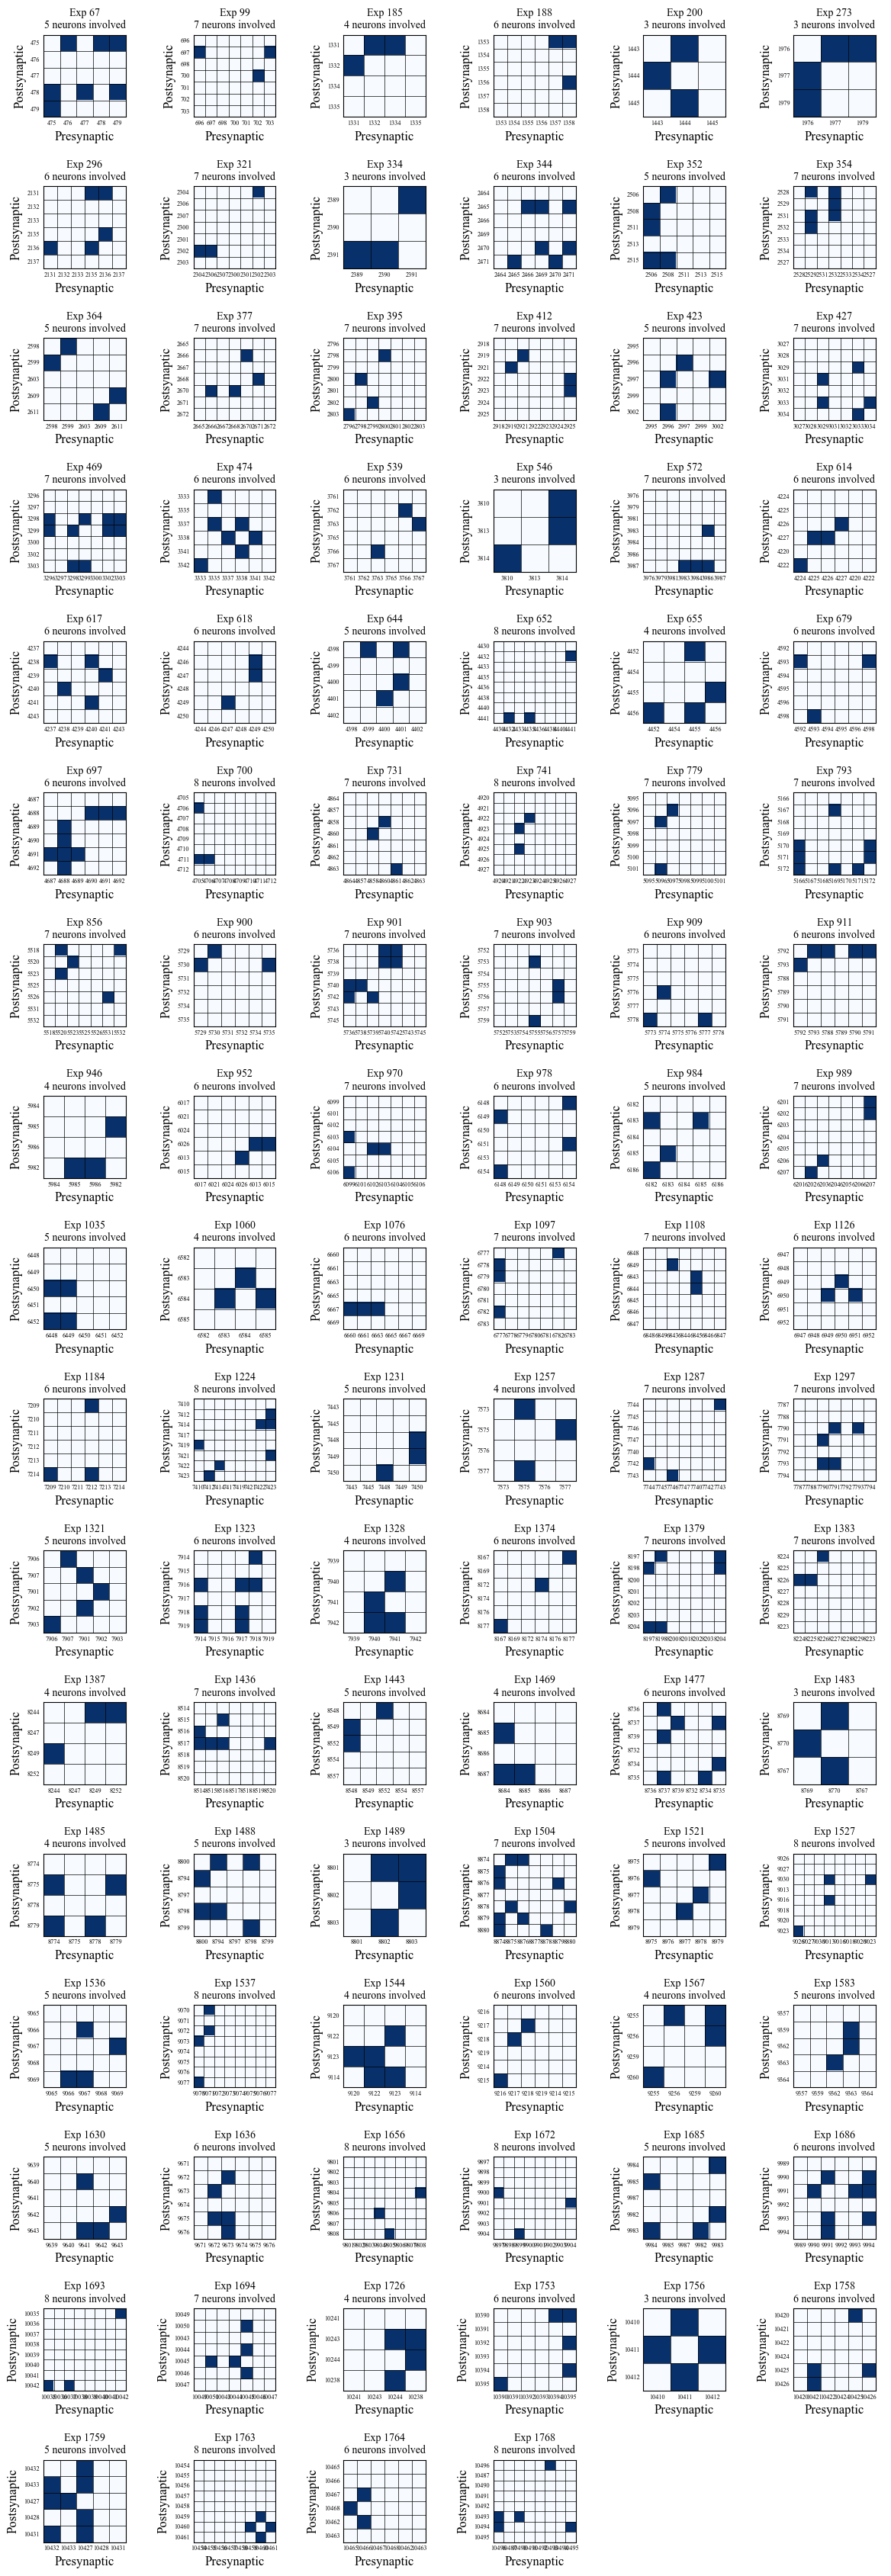

In [ ]:
completed_experiments = []

# -------------------- Specific experiments --------------------
# Query for experiments satisfying a specific criteria, here above a certain number of synapses

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

# valid_experiments = df_num_synapses["experiment_id"].tolist()
# was_synapse = df_was_synapse["experiment_id"].unique().tolist()
experiment_ids = experiments["experiment_id"].unique().tolist()

# for exp in valid_experiments:  # uncomment if wall experiments
# for exp in was_synapse:  # only when there was a synapse
for exp in experiment_ids:
    df = df_valid_experiments[(df_valid_experiments["experiment_id"]==exp)]
    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    total_neurons = list(set(pres) | set(posts))
    n = len(total_neurons)
    possible_synapses = n * (n - 1)

    df_distinct_cells = df[df["pre_cell_id"] != df["post_cell_id"]]  # distinct cells in pre and post
    unique_synapses = df_distinct_cells[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # drop duplicates

    if len(unique_synapses == possible_synapses):
        completed_experiments.append((exp, df, total_neurons))


print(f"Total experiments: {len(completed_experiments)}")
# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(completed_experiments))
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    adj = np.zeros((n, n))

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0  # row is postsynaptic, column is presynaptic


    ax = axs[i]
    im = ax.imshow(adj, cmap="Blues", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)

    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)


    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

# Motif stuff

* Preprocessing to get only relevant data
    * Know when a synapse occurred or not
    * Ensure we inclue only when we could have possibly observed a motif


loop over the list of observed synapses and count:

- **Reciprocal motifs**: if both A→B and B→A exist.
- **Divergent motifs**: one neuron projecting to two.
- **Convergent motifs**: two neurons projecting to the same one.
- **Chain motifs**: A→B→C.

avoid counting the same motif multiple times (e.g., by imposing a condition such as `pre1 < pre2`).


**Motif score**
To quantify how "special" a motif is: z-score **τ**.  
if a given motif is **more or less frequent than expected by chance**, assuming synapses are formed independently.


τ = (p_motif - p²) / σ²

- `p_motif` is the observed frequency of the motif.
- `p` is the overall connection probability.
- `σ² = p(1 - p)` is the variance under a Bernoulli model.

I use the same dataset as in the other cases, i.e. where I can obtain f-I slope for neurons as well.

In [28]:
dfA# DF to CSV
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()

dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


## Frequency of possible motifs and actual motifs

These functions calculate possible motifs. To calculate the possible motifs we take the dataframe where the 'has_synapse' column takes values ​​0 or 1, that is, the measurement was performed and it was determined whether there are ('has_synapse' = 1) or no ('has_synapse' = 0) synapses. The functions are:

```
    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)
```

**Then**, we count motifs that are actually present in the data. To do that, we use the subset of connections where synapses were detected ('has_synapse' = 1). We use the same functions as before, i.e.:

```

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)
```

In [15]:
from itertools import combinations
#### Functions to compute motifs
# If has_synapse can be both 0 and 1, it counts possible motifs. If has_synapse can only be 1, it compute motifs observed.

df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()

def count_reciprocal(df):
    ''' 
    Maps whether synapses exist in each direction
     
    '''
    connectivity = set(map(tuple, df[['pre_cell_id','post_cell_id']].values))
    rec = 0

    # Iterate over unordered combinations of pairs of neurons (take combinations, then count pairs of connections only once)

    neurons = df['pre_cell_id'].unique()
    for a, b in combinations(neurons, 2):
        # Does A→B and B→A exist?
        if (a,b) in connectivity and (b,a) in connectivity:
            rec += 1

    return rec


def count_divergent(df):
    ''' 
    For each presynaptic, look at its posts and choose pairs of posts  
    '''
    div = 0
    for pre, subdf in df.groupby('pre_cell_id'):
        posts = subdf['post_cell_id'].unique()
        for post1, post2 in combinations(posts, 2):
            if post1 == post2 or post1 == pre or post2 == pre:
                continue
            div += 1

    return div


def count_convergent(df):
    '''
    For each postsynaptic, look at its pres and choose pairs of pres
    '''
    con = 0
    for post, subdf in df.groupby('post_cell_id'):
        pres = subdf['pre_cell_id'].unique()
        for pre1, pre2 in combinations(pres, 2):
            if pre1 == post or pre2 == post:
                continue
            con += 1

    return con


def count_chain(df):
    '''
    Gamma is an intermediate node: it appears as a post in one connection and a pre in another
    '''
    chn = 0
    for gamma in set(df['pre_cell_id']).intersection(df['post_cell_id']):
        ins  = df[df['post_cell_id']==gamma]  # conexiones pre→gamma
        outs = df[df['pre_cell_id']==gamma]   # conexiones gamma→post
        pres = ins['pre_cell_id'].unique()
        posts = outs['post_cell_id'].unique()
        # Combina cada pre con cada post
        for pre, post in ((p, q) for p in pres for q in posts):
            if pre in (gamma, post) or post in (gamma, pre):
                continue
            chn += 1

    return chn




##### Example

df_valid_experiments = dfA.copy()  # The functions handle unique cell IDs

# df_cleaned = dfA.dropna(subset=["psp_amplitude"])  # Need to decide if we exclude these or not in order to always use exactly the same amount of data across different things

# Count possible motifs - at this point, has_synapse can be either 0 or 1
print("=== Possible motifs ===")
possible_rec = count_reciprocal(df)
possible_div = count_divergent(df)
possible_con = count_convergent(df)
possible_chn = count_chain(df)
possibles = [possible_rec, possible_div, possible_con, possible_chn]
for p in possibles:
    print(p)

# Count actual motifs
print("=== Actual motifs ===")
df_syn = df_valid_experiments[(df_valid_experiments['has_synapse'] == 1)]
rec_count = count_reciprocal(df_syn)
div_count = count_divergent(df_syn)
con_count = count_convergent(df_syn)
chn_count = count_chain(df_syn)
motif_counts = [rec_count, div_count, con_count, chn_count]
for m in motif_counts:
    print(m)


# print(f"Across all experiments there are {count_reciprocal(df_valid_experiments)} reciprocal motifs, {count_divergent(df_valid_experiments)} divergent motifs, {count_convergent(df_valid_experiments)} convergent motifs, {count_chain(df_valid_experiments)} chain motifs.")

# print(f"If we exclude entries that does not measure PSP amplitude, it is across all experiments {count_reciprocal(df_cleaned)} reciprocal motifs, {count_divergent(df_cleaned)} divergent motifs, {count_convergent(df_cleaned)} convergent motifs, {count_chain(df_cleaned)} chain motifs.")



=== Possible motifs ===
3984
10070
10070
20140
=== Actual motifs ===
167
234
221
363


## Compute motif z score

In [16]:
def safe_divide(n, d):
    '''Returns np.nan if the denominator is zero'''
    return n / d if d != 0 else np.nan

def compute_tau(count_motif, count_possible, sigma2, p):
    '''Compute tau'''
    p_motif = safe_divide(count_motif,count_possible)
    return safe_divide((p_motif-p**2),sigma2)

def compute_motifs(df):

    '''
    This function computes the motifs by utilizing the other functions.
    It first get counts of possible motifs.
    It then computes motifs that actually occurred.
    It then computes p (overall connection probability).
    It then calculate sigma^2.
    Finally, it passes these to the function that computes tau (the z score), and return that.
    '''

    # Possible motif count

    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)

    # Actual motif count

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)


    # Return nan if no synapses

    if len(df_syn) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    
    
    # calculate p

    p = len(df_syn) / len(df)  
    
    # calculate sigma^2

    sigma2 = p * (1 - p)  

    # Get tau (z-score)

    tau_rec = compute_tau(rec_count, possible_rec, sigma2, p)
    tau_div = compute_tau(div_count, possible_div, sigma2, p)
    tau_con = compute_tau(con_count, possible_con, sigma2, p)
    tau_chn = compute_tau(chn_count, possible_chn, sigma2, p)
   

    # Return tau (z-score)
    return tau_rec, tau_div, tau_con, tau_chn

df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()
tau_rec, tau_div, tau_con, tau_chn = compute_motifs(dfA)

print(f"Tau/z-score is:\n  Reciprocal: {tau_rec}\n  Divergent: {tau_div}\n  Convergent: {tau_con}\n  Chain: {tau_chn}")

Tau/z-score is:
  Reciprocal: 0.3329487992600748
  Divergent: 0.13275627769533999
  Convergent: 0.1189213421614828
  Chain: 0.07688442265476278


## Tau / z-score (motifs) across slope categories

## New

In [17]:
fi_slopes = ["small", "medium", "high"]
# cell_fislope_analyzed = "post"
measuretype = ""
measuretype = "_pct"
measuretype = "_quart"

df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# wDF_2 = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns

dfA = df.copy()
cats = ["small", "medium", "high"]

experiments = dfA["experiment_id"].unique()
n_experiments = len(experiments)

# Store motifs to compute averages
av_rec=[]
av_div=[]
av_con=[]
av_chn=[]

rows = []

for cat in cats:
    current_fi_slope = dfA[dfA[f"post_fi_category{measuretype}"]==cat]

    if len(current_fi_slope) == 0:
        continue  # skip if there was no data for that category

    elif len(current_fi_slope) > 0:

        # dfM = current_fi_slope[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # remove duplicate connections
        dfM = current_fi_slope.drop_duplicates(
                subset=['pre_cell_id', 'post_cell_id'],
                keep='first'          # keep the first occurrence (default)
        )

        tau_rec, tau_div, tau_con, tau_chn = compute_motifs(dfM)  # Compute tau (z-score)

        # Append all tau/z-score to a list
        # av_rec.append(tau_rec)
        # av_div.append(tau_div)
        # av_con.append(tau_con)
        # av_chn.append(tau_chn)

        row = [cat, tau_rec, tau_div, tau_con, tau_chn]
        rows.append(row)




            

        # for psp in psp_amplitudes:  # If there is more, store one row per
        #     row = [exp, cat, psp]  
        #     rows.append(row)

for r in rows:
    print(r)


columns = ["fi_slope", "tau_rec", "tau_div", "tau_con", "tau_chn"]
dfMotif = pd.DataFrame(rows, columns=columns)



['small', 0.42161613790327995, -0.009470713236056316, 0.12329574495442794, 0.33086101134763024]
['medium', 0.25753815521880324, 0.1318688187345394, 0.07878197584433466, 0.06229630729726217]
['high', 0.4945272513642988, 0.27423262479332194, 0.1213918928377584, 0.1846822991084963]


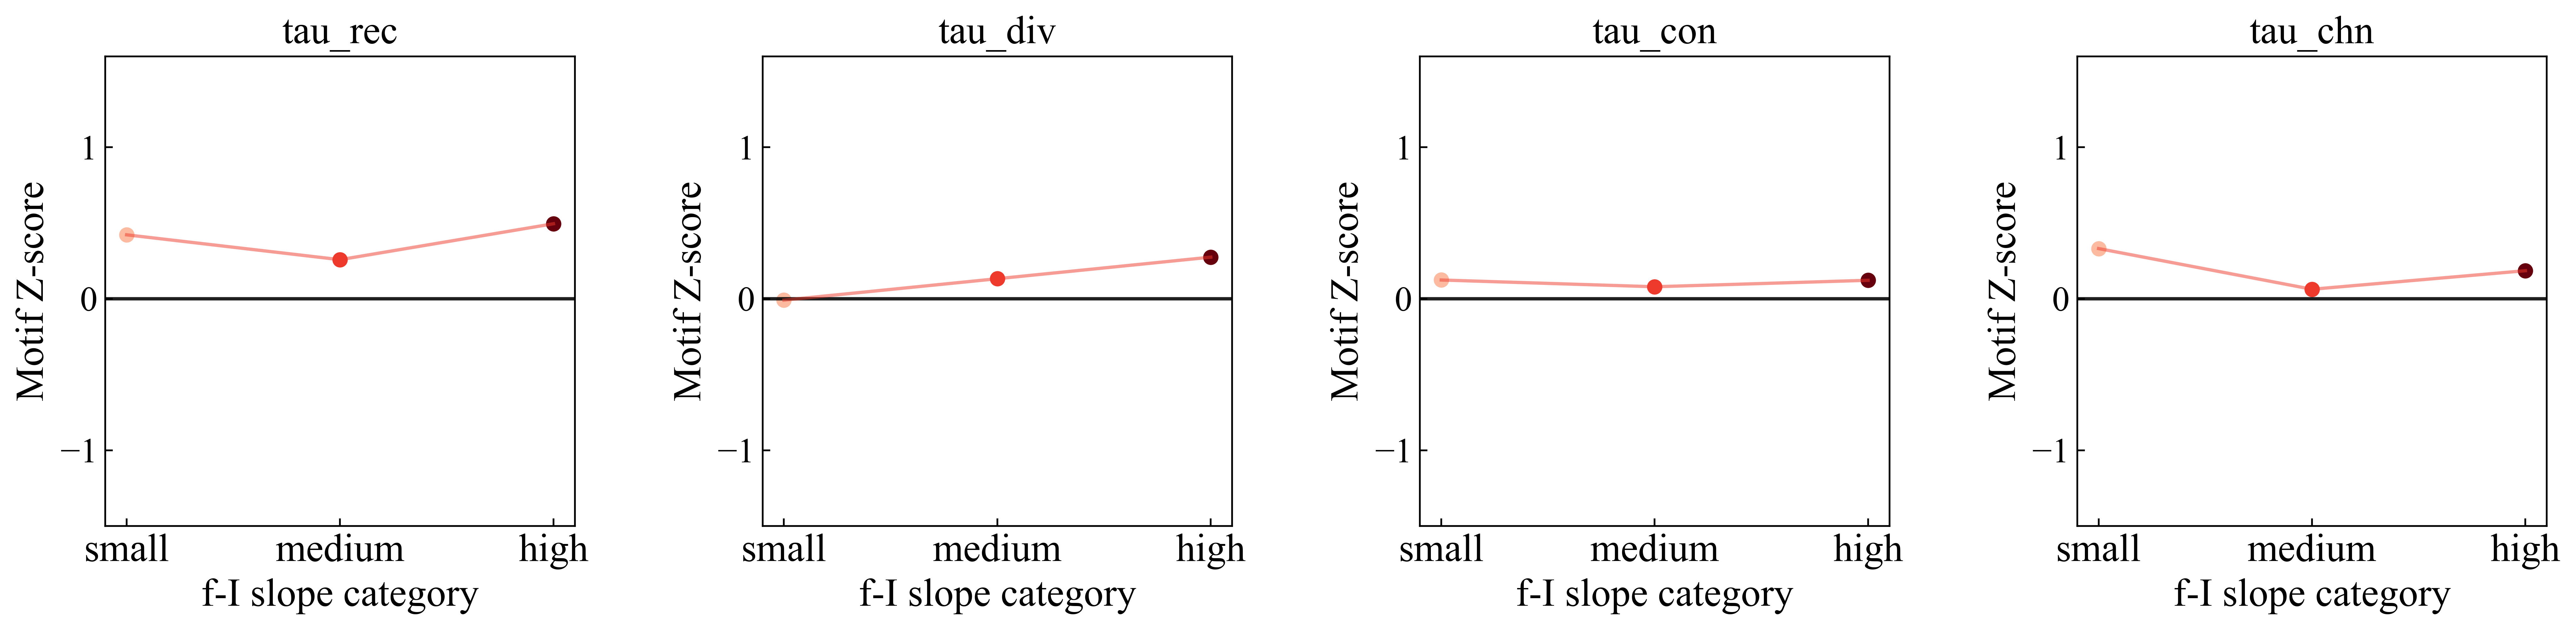

In [18]:
dfMotif
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 8))
fig.subplots_adjust(hspace=0.1, wspace=0.4)

taus = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

for i, t in enumerate(taus):

    fi_line = []

    ax = axs[i]

    for fi in fi_slopes:


        df = dfMotif[(dfMotif["fi_slope"]==fi)]
        y = df[t]
        fi_line.append(y)

        # yerr = df[t]

        ax.scatter(fi, y, color=color_map_vrest[fi])
        ax.set_title(f"{t}")
        ax.set_box_aspect(1)
        ax.axhline(0, color='black', alpha=0.5)
        ax.set_ylim(-1.5, 1.6)
        ax.set_xlabel("f-I slope category")
        ax.set_ylabel(f"Motif Z-score")

    ax.plot(fi_slopes, fi_line, color=color_map_vrest["medium"], alpha=0.5)

# plt.suptitle(f"Z-score motif vs. f-I slope ({measuretype})")
plt.show()

In [35]:
dfMotif

,fi_slope,tau_rec,tau_div,tau_con,tau_chn
0,small,0.421616,-0.009471,0.123296,0.330861
1,medium,0.257538,0.131869,0.078782,0.062296
2,high,0.494527,0.274233,0.121392,0.184682


PSP Matrix: original functions and functions that handle NaN

In [ ]:
# Convert the dataframe to a numpy array
psp_matrix_numpy = df_psp_matrix.values

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn


def motifs_zero_filled(w, N):
    """
    Same as original function, but first replace NaNs by 0.
    """
    #  Replace missing entries by 0 (no connection)
    w = np.nan_to_num(w, nan=0.0)

    # Center the matrix using the *overall* mean (now a finite number)
    w = w - np.mean(w)

    # The rest of the algebra is like above
    ww = np.matmul(w, w)
    wtw = np.matmul(w.T, w)
    wwt = np.matmul(w, w.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


def motifs_nan_aware(w, N):
    """
    Compute the motif scores while ignoring NaNs when calculating the mean.
    Unmeasured entries are treated as 0 after the centering step.
    """
    # Compute the mean over the *observed* entries only
    w_centered = w - np.nanmean(w)          # nan‑safe mean

    # Replace any still‑nan entries (the ones that were never measured) by 0 so that the matrix algebra can continue.
    w_centered = np.nan_to_num(w_centered, nan=0.0)

    # Continue with the original algebra
    ww = np.matmul(w_centered, w_centered)
    wtw = np.matmul(w_centered.T, w_centered)
    wwt = np.matmul(w_centered, w_centered.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn

   


# Modify the output print to get values as simple floats
# result = motifs(psp_matrix_numpy, len(all_cells))
# print(f"tau_rec: {result[0].item():.5f}, tau_div: {result[1].item():.5f}, tau_con: {result[2].item():.5f}, tau_chn: {result[3].item():.5f}")

The problem with the code below is that we remove all cases where a synapse occurred. Should not be used to plot motifs, but I keep it for now because I want to later plot some PSP matrices where there actually is values

In [87]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


In [50]:
df_MotifVal

,experiment_id,pop_size,post_cell_id,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,3,4140,1.131452e-13,small,0.000000,0.000000,0.000000,-0.500000
1,600,3,4133,8.230065e-13,high,0.000000,0.000000,0.000000,-0.500000
2,610,2,4201,7.692308e-14,small,NaN,NaN,NaN,NaN
3,614,2,4227,2.000000e-13,medium,NaN,NaN,NaN,NaN
4,699,2,4700,-1.269841e-14,neg,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1187,5004,2,24814,1.739197e-13,medium,-0.180961,-0.180961,0.042882,-0.361921
1188,5004,2,24814,1.739197e-13,medium,-0.180961,-0.180961,0.042882,-0.361921
1189,5105,2,24814,9.525691e-14,small,-0.333333,-0.333333,-0.333333,-0.666667
1190,5108,2,24814,6.639170e-14,small,-0.333333,-0.333333,-0.333333,-0.666667


Motifs but according to cell class

In [88]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


In [138]:
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
df_experiments = df.copy()

df_experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,post_cell_class,fi_slope_pre,fi_slope_post,post_fi_category,post_fi_category_pct,post_fi_category_quart,psp_amplitude,synapse_id,post_mu,post_sigma
0,600,4133,4138,0,in,8.230065e-13,1.105000e-12,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13
1,600,4133,4140,0,ex,8.230065e-13,1.131452e-13,medium,small,medium,NaN,NaN,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,8.230065e-13,8.820777e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,1.105000e-12,8.230065e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
4,600,4138,4140,1,ex,1.105000e-12,1.131452e-13,medium,small,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,ex,4.244768e-13,6.639170e-14,medium,small,small,-0.000314,3391.0,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,in,3.932555e-13,5.590663e-13,medium,high,medium,NaN,NaN,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,mixed,5.590663e-13,3.932555e-13,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,in,7.079645e-14,7.336674e-13,medium,high,high,0.000379,3374.0,4.713725e-13,5.964395e-13


In [134]:
import math
import pandas as pd
import numpy as np
# ------------------------------------------------------------


# Get dataframe from main query
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
df_experiments = df.copy()


# df_experiments = df_experiments.dropna(subset=['psp_amplitude'])

# f-I slope categorization
# measuretype = '_pct'

# ------------------------------------------------------------
# Functions computing motifs

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn


def motifs_zero_filled(w, N):
    """
    Same as original function, but first replace NaNs by 0.
    """
    #  Replace missing entries by 0 (no connection)
    w = np.nan_to_num(w, nan=0.0)

    # Center the matrix using the *overall* mean (now a finite number)
    w = w - np.mean(w)

    # The rest of the algebra is like above
    ww = np.matmul(w, w)
    wtw = np.matmul(w.T, w)
    wwt = np.matmul(w, w.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


def motifs_nan_aware(w, N):
    """
    Compute the motif scores while ignoring NaNs when calculating the mean.
    Unmeasured entries are treated as 0 after the centering step.
    """
    # Compute the mean over the *observed* entries only
    w_centered = w - np.nanmean(w)          # nan‑safe mean

    # Replace any still‑nan entries (the ones that were never measured) by 0 so that the matrix algebra can continue.
    w_centered = np.nan_to_num(w_centered, nan=0.0)

    # Continue with the original algebra
    ww = np.matmul(w_centered, w_centered)
    wtw = np.matmul(w_centered.T, w_centered)
    wwt = np.matmul(w_centered, w_centered.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


import numpy as np

def motifs_safe(w: np.ndarray, N: int):
    """
    Compute the four motif scores in a completely safe way.

    `w` may contain NaNs (missing connections).  
    Missing entries are treated as “no connection” (0) after the centering step.  
    If the matrix is completely empty **or** its variance is zero, the function
      returns (nan, nan, nan, nan) instead of raising warnings.

    Returns
    -------
    tau_rec, tau_div, tau_con, tau_chn : float
    """
    # ------------------------------------------------------------------

    # All‑NaN check

    if np.isnan(w).all():
        return (np.nan, np.nan, np.nan, np.nan)

    # ------------------------------------------------------------------

    # NaN‑aware centring (mean of observed entries only)

    w_centered = w - np.nanmean(w)           # nan‑safe mean
    w_centered = np.nan_to_num(w_centered, nan=0.0)   # unobserved → 0

    # ------------------------------------------------------------------

    # Core algebra (identical to the original formulas)
    ww  = w_centered @ w_centered
    wtw = w_centered.T @ w_centered
    wwt = w_centered @ w_centered.T

    sigma2 = np.trace(wwt) / N

    # ------------------------------------------------------------------

    #  Guard against zero variance or a single‑cell experiment
    if sigma2 == 0 or np.isnan(sigma2) or N <= 1:
        # No variability in the connectivity → motifs are undefined
        return (np.nan, np.nan, np.nan, np.nan)

    # ------------------------------------------------------------------

    # Compute the four motif scores (now safe)
    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn



def is_all_nan(mat: np.ndarray) -> bool:
    """True if the matrix has no finite (non‑NaN, non‑inf) entry."""
    return not np.isfinite(mat).any()

# ------------------------------------------------------------

# Get experiment IDs
valid_experiments = df_experiments["experiment_id"].unique()
n_experiments = len(valid_experiments) 
print(f"Looping through {n_experiments} experiments")

# Containers
exp_gains = {}
exp_motifs = {}
rows_motif = []

empty = 0
rows = []


# ------------------------------------------------------------
# LOOP

if n_experiments == 0: # If there are no experiments, do nothing
    print("No experiments with sufficient data were found.")
else:
    # ------------------------------------------------------------
    # Figure preparation
    # n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    # n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))  # Determine figure size based on number of subplots
    # axes = axes.flatten()  # Flatten the axes array for easier access

    # ------------------------------------------------------------
    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiments):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]  # Only data points from this experiment
        psps_nonan = df_exp["psp_amplitude"].count () # counts number of records that are not NaN
        if psps_nonan==0:
            # if no psp amplitude was measured, skip the experiment and increase the empty counter
            empty += 1
            continue  

        # Containers
        pres_fi = []
        posts_fi = []
        posts_fi_category = []

        # Generate PSP matrix for the experiment
        all_cells = np.sort(pd.unique(df_exp[['pre_cell_id', 'post_cell_id']].values.ravel()))  # To get matrix size
        df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)  # Initialize empty matrix

        pop_size = len(all_cells)
        for _, row in df_exp.iterrows():  # Iterate through all rows of current experiment
            pre_cell = row['pre_cell_id']  # Pre cell
            post_cell = row['post_cell_id']  # Post cell
            # pre_cell_class = row['pre_cell_class']  # 
            # post_cell_class = row['post_cell_class']  # 
            psp_value = row['psp_amplitude']  # PSP amplitude

            # ------------------------------------------------------------
            # Store PSP amplitudes in a matrix for all pre and post cells

            # df_psp_matrix.loc[pre_cell, post_cell] = psp_value
            df_psp_matrix.loc[post_cell, pre_cell] = psp_value  # One entry in the matrix


            # ------------------------------------------------------------
            # One row for this postsynaptic cell
            # post_cell_fi = row['fi_slope_post']
            # posts_fi.append(post_cell_fi)

            # post_cell_fi_cat = row[f'post_fi_category{measuretype}']
            # posts_fi_category.append(post_cell_fi_cat)


            rows.append({
                'experiment_id' : experiment_id,
                'pop_size'      : pop_size,                 # will be repeated
                'pre_cell_id' : pre_cell,
                'post_cell_id'  : post_cell,
                'fi_slope'      : row['fi_slope_post']
                # the motif scores (added later) will also be repeated
            })

        # ------------------------------------------------------------

        # Motif calculation



        psp_matrix_numpy = df_psp_matrix.values.astype(float)
        # If the whole matrix is NaN we don't plot it
        if is_all_nan(psp_matrix_numpy):
            # if true, there was no connections at all
            tau_rec, tau_div, tau_con, tau_chn = (np.nan, np.nan, np.nan, np.nan)
        else:

            # tau_rec, tau_div, tau_con, tau_chn = motifs_zero_filled(psp_matrix_numpy, len(all_cells))
            # tau_rec, tau_div, tau_con, tau_chn = motifs_nan_aware(psp_matrix_numpy, len(all_cells))
            tau_rec, tau_div, tau_con, tau_chn = motifs_safe(psp_matrix_numpy, len(all_cells))

            

            # Add to all rows belonging to this experiment
            for row in rows[-len(df_exp):]:   # only the rows we just added
                row.update({
                    'tau_rec' : tau_rec,
                    'tau_div' : tau_div,
                    'tau_con' : tau_con,
                    'tau_chn' : tau_chn
                })

        # ------------------------------------------------------------


# ------------------------------------------------------------
# Assemble dataframe

df_all = pd.DataFrame(rows,
                      columns=['experiment_id',
                               'pop_size',
                               'pre_cell_id',
                               'pre_cell_class',
                               'post_cell_id',
                               'post_cell_class',
                               'fi_slope',
                               'fi_category',
                               'tau_rec',
                               'tau_div',
                               'tau_con',
                               'tau_chn'])


# Can print experiment summary by using this (i.e. drop the repeating info per cell)
df_experiment_summary = df_all[['experiment_id','pop_size',
                                'tau_rec','tau_div','tau_con','tau_chn']] \
                        .drop_duplicates().reset_index(drop=True)


df_MotifVal2 = df_all.copy()

Looping through 878 experiments


In [135]:
df_MotifVal2

,experiment_id,pop_size,pre_cell_id,pre_cell_class,post_cell_id,post_cell_class,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,4,4133,NaN,4138,NaN,1.105000e-12,NaN,0.0,0.0,0.0,-0.333333
1,600,4,4133,NaN,4140,NaN,1.131452e-13,NaN,0.0,0.0,0.0,-0.333333
2,600,4,4133,NaN,4142,NaN,8.820777e-13,NaN,0.0,0.0,0.0,-0.333333
3,600,4,4138,NaN,4133,NaN,8.230065e-13,NaN,0.0,0.0,0.0,-0.333333
4,600,4,4138,NaN,4140,NaN,1.131452e-13,NaN,0.0,0.0,0.0,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
3682,5105,2,24781,NaN,24778,NaN,8.018796e-13,NaN,NaN,NaN,NaN,NaN
3683,5108,2,24790,NaN,24791,NaN,4.244768e-13,NaN,NaN,NaN,NaN,NaN
3684,5108,2,24791,NaN,24790,NaN,6.639170e-14,NaN,NaN,NaN,NaN,NaN
3685,5117,2,24813,NaN,24814,NaN,7.336674e-13,NaN,NaN,NaN,NaN,NaN


In [136]:
df_MotifVal2

motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']

df_all_nan_motifs = df_MotifVal2[df_MotifVal2[motifs].isna().all(axis=1)]

df_all_nan_motifs
df_MotifVal2
dfMotif = df_MotifVal2.copy()

dfMotif

,experiment_id,pop_size,pre_cell_id,pre_cell_class,post_cell_id,post_cell_class,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,4,4133,NaN,4138,NaN,1.105000e-12,NaN,0.0,0.0,0.0,-0.333333
1,600,4,4133,NaN,4140,NaN,1.131452e-13,NaN,0.0,0.0,0.0,-0.333333
2,600,4,4133,NaN,4142,NaN,8.820777e-13,NaN,0.0,0.0,0.0,-0.333333
3,600,4,4138,NaN,4133,NaN,8.230065e-13,NaN,0.0,0.0,0.0,-0.333333
4,600,4,4138,NaN,4140,NaN,1.131452e-13,NaN,0.0,0.0,0.0,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
3682,5105,2,24781,NaN,24778,NaN,8.018796e-13,NaN,NaN,NaN,NaN,NaN
3683,5108,2,24790,NaN,24791,NaN,4.244768e-13,NaN,NaN,NaN,NaN,NaN
3684,5108,2,24791,NaN,24790,NaN,6.639170e-14,NaN,NaN,NaN,NaN,NaN
3685,5117,2,24813,NaN,24814,NaN,7.336674e-13,NaN,NaN,NaN,NaN,NaN


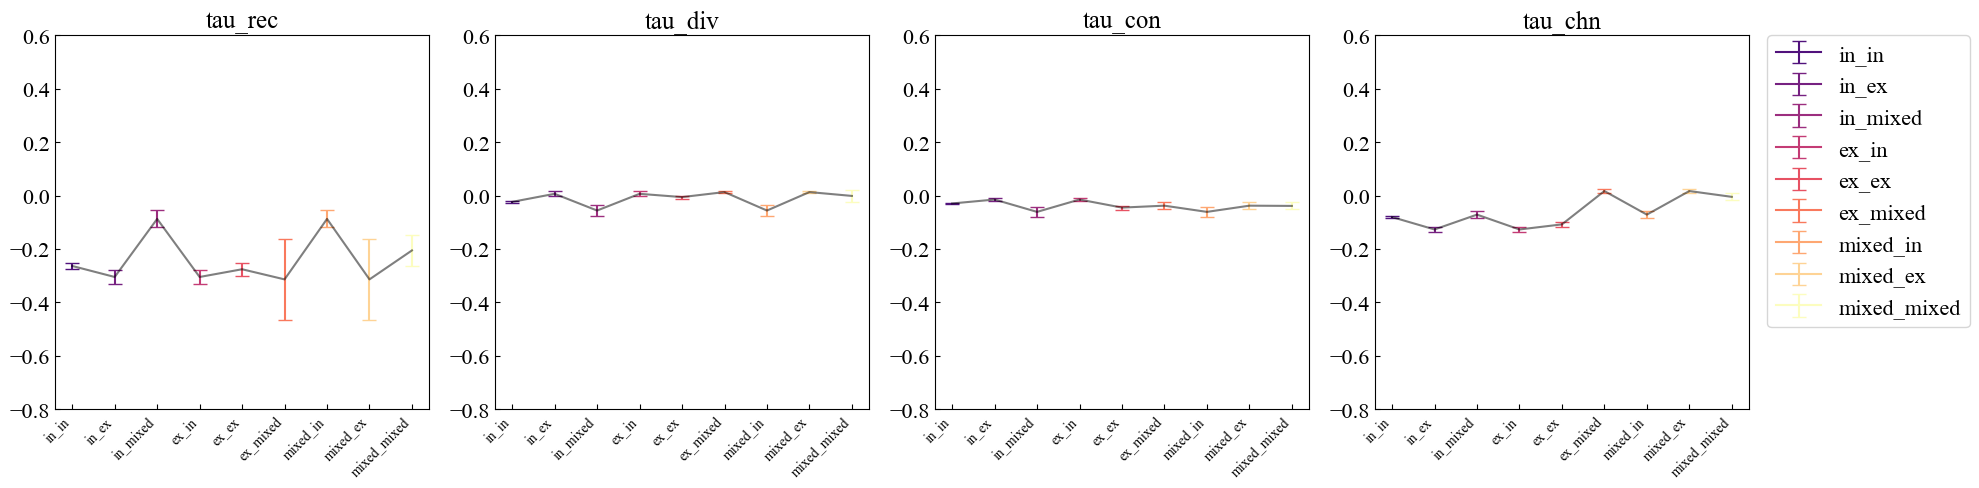

In [78]:

pre_classes = dfMotif['pre_cell_class'].unique()
post_classes = dfMotif['post_cell_class'].unique()
pairs = [f'{pre}_{post}' for pre in pre_classes for post in post_classes]

motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']
rows = []

all_comb = {}

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# Make colors once
color_map_pairs = make_color_map(pairs, plt.cm.magma)  
# color_map_greens = make_color_map(slope, plt.cm.Greens)


fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,10))
for i, t in enumerate(motifs):
    ax = axs[i]
    meanvals = []
    for pre in pre_classes:
        for post in post_classes:  # Now gets all combinations
            sub = dfMotif[(dfMotif['pre_cell_class'] == pre) & (dfMotif['post_cell_class'] == post)]

            # Mean of current motif across experiments
            mean_motif = sub[t].mean()  
            meanvals.append(mean_motif)

            # Standard deviation of motifs across experiments
            std_motif = sub[t].std() 
            sem_motif = sub[t].sem() 
            stdvals.append(std_motif)

            comb = f"{pre}_{post}"

            # all_comb[comb] = mean_motif

            ax.errorbar(comb, mean_motif, yerr=sem_motif, capsize=5, label=comb, color=color_map_pairs[f"{pre}_{post}"])
            ax.set_box_aspect(1)
            ax.set_title(t)
            ax.set_ylim(-0.80, 0.60)
            ax.set_xticks(np.arange(len(pairs)))
            ax.set_xticklabels(pairs, rotation=45, ha='right', fontsize=10)

    ax.plot(pairs, meanvals, color='black', alpha=0.5)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [39]:
dfMotif

,experiment_id,fi_slope,tau_rec,tau_div,tau_con,tau_chn
0,600,small,NaN,NaN,-0.500,NaN
1,600,high,-0.125,-0.125,-0.125,-0.125
2,605,small,NaN,NaN,NaN,NaN
3,605,medium,NaN,NaN,NaN,NaN
4,605,high,NaN,NaN,-1.000,NaN
...,...,...,...,...,...,...
1539,5108,medium,NaN,NaN,NaN,NaN
1540,5110,medium,NaN,NaN,NaN,NaN
1541,5110,high,NaN,NaN,NaN,NaN
1542,5117,small,NaN,NaN,NaN,NaN


## Motif value on PSP matrix

In [9]:
import pandas as pd
df = pd.read_csv("preprocessed_data.csv")
dfA = df.copy()

In [27]:
import os


# DF to CSV
df = dfMotif.copy()

# Categorization
measuretype = ""
measuretype = "_quart"
measuretype = "_pct"
cats = ["small", "medium", "high"]
motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']


experiment_ids = df["experiment_id"].unique()  # Get unique experiment ids
n_experiments = len(experiment_ids)  # how many experiments

rows = []

excluded = 0 # count how many was excluded


stdvals = []

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,10))
plt.subplots_adjust(hspace=0.5, wspace=0.5)
for i, t in enumerate(motifs):
    ax = axs[i]
    meanvals = []
    for cat in cats:
        df_filtered = df[(df[f"fi_slope"]==cat)]  # this category across experiments

        # Mean of current motif across experiments
        mean_motif = df_filtered[t].mean()  
        meanvals.append(mean_motif)

        # Standard deviation of motifs across experiments
        std_motif = df_filtered[t].std()
        sem_motif = df_filtered[t].sem()  
        # stdvals.append(std_psp)

        ax.errorbar(cat, mean_motif, yerr=sem_motif, capsize=5, color=color_map_vrest[cat])

    ax.plot(cats, meanvals, color=color_map_vrest['medium'])
    ax.set_title(t)
    ax.set_ylim(-0.8, 0.4)
    ax.set_ylabel("Motif value")
    ax.set_xlabel("f-I Slope")
    ax.set_box_aspect(1)
plt.show()

# Histogram
import numpy as np
import matplotlib.pyplot as plt


# histovals = []

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# To be given value
motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']
max_abs = np.nanmax(np.abs(dfMotif[motifs].values))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 40)
# slope_reversed = list(reversed(slope))

# Make colors once
color_map_motifs = make_color_map(motifs, plt.cm.Blues)  
# color_map_greens = make_color_map(slope, plt.cm.Greens)



fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
for i, t in enumerate(motifs):
    ax = axs
    motif = df_filtered[t]

    ax.hist(motif, bins=bins, histtype='step', linewidth=1.5, color=color_map_motifs[t], alpha=0.8, label=t)

ax.set_ylabel("Frequency")
ax.set_xlabel("Motif value")
plt.title("Motif Frequency (no categories of f-I slope)")
plt.legend()
plt.show()

NameError: name 'dfMotif' is not defined

In [10]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,-0.000204
...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,-0.000314
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,NaN
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,NaN
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,0.000379


Non-empty experiments to plot: 153
Empty experiments (all NaN): 156
     Skipped IDs: [np.int64(651), np.int64(688), np.int64(732), np.int64(739), np.int64(771), np.int64(780), np.int64(862), np.int64(898), np.int64(934), np.int64(940), np.int64(1003), np.int64(1079), np.int64(1117), np.int64(1121), np.int64(1187), np.int64(1218), np.int64(1221), np.int64(1306), np.int64(1330), np.int64(1378), np.int64(1379), np.int64(1472), np.int64(1497), np.int64(1505), np.int64(1523), np.int64(1525), np.int64(1528), np.int64(1531), np.int64(1532), np.int64(1530), np.int64(1537), np.int64(1542), np.int64(1572), np.int64(1577), np.int64(1579), np.int64(1584), np.int64(1600), np.int64(1643), np.int64(1655), np.int64(1668), np.int64(1671), np.int64(1674), np.int64(1682), np.int64(1718), np.int64(1722), np.int64(1735), np.int64(1746), np.int64(1775), np.int64(1779), np.int64(1782), np.int64(1785), np.int64(1789), np.int64(1793), np.int64(1799), np.int64(1805), np.int64(1806), np.int64(1815), np.int64(18

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\4180095563.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


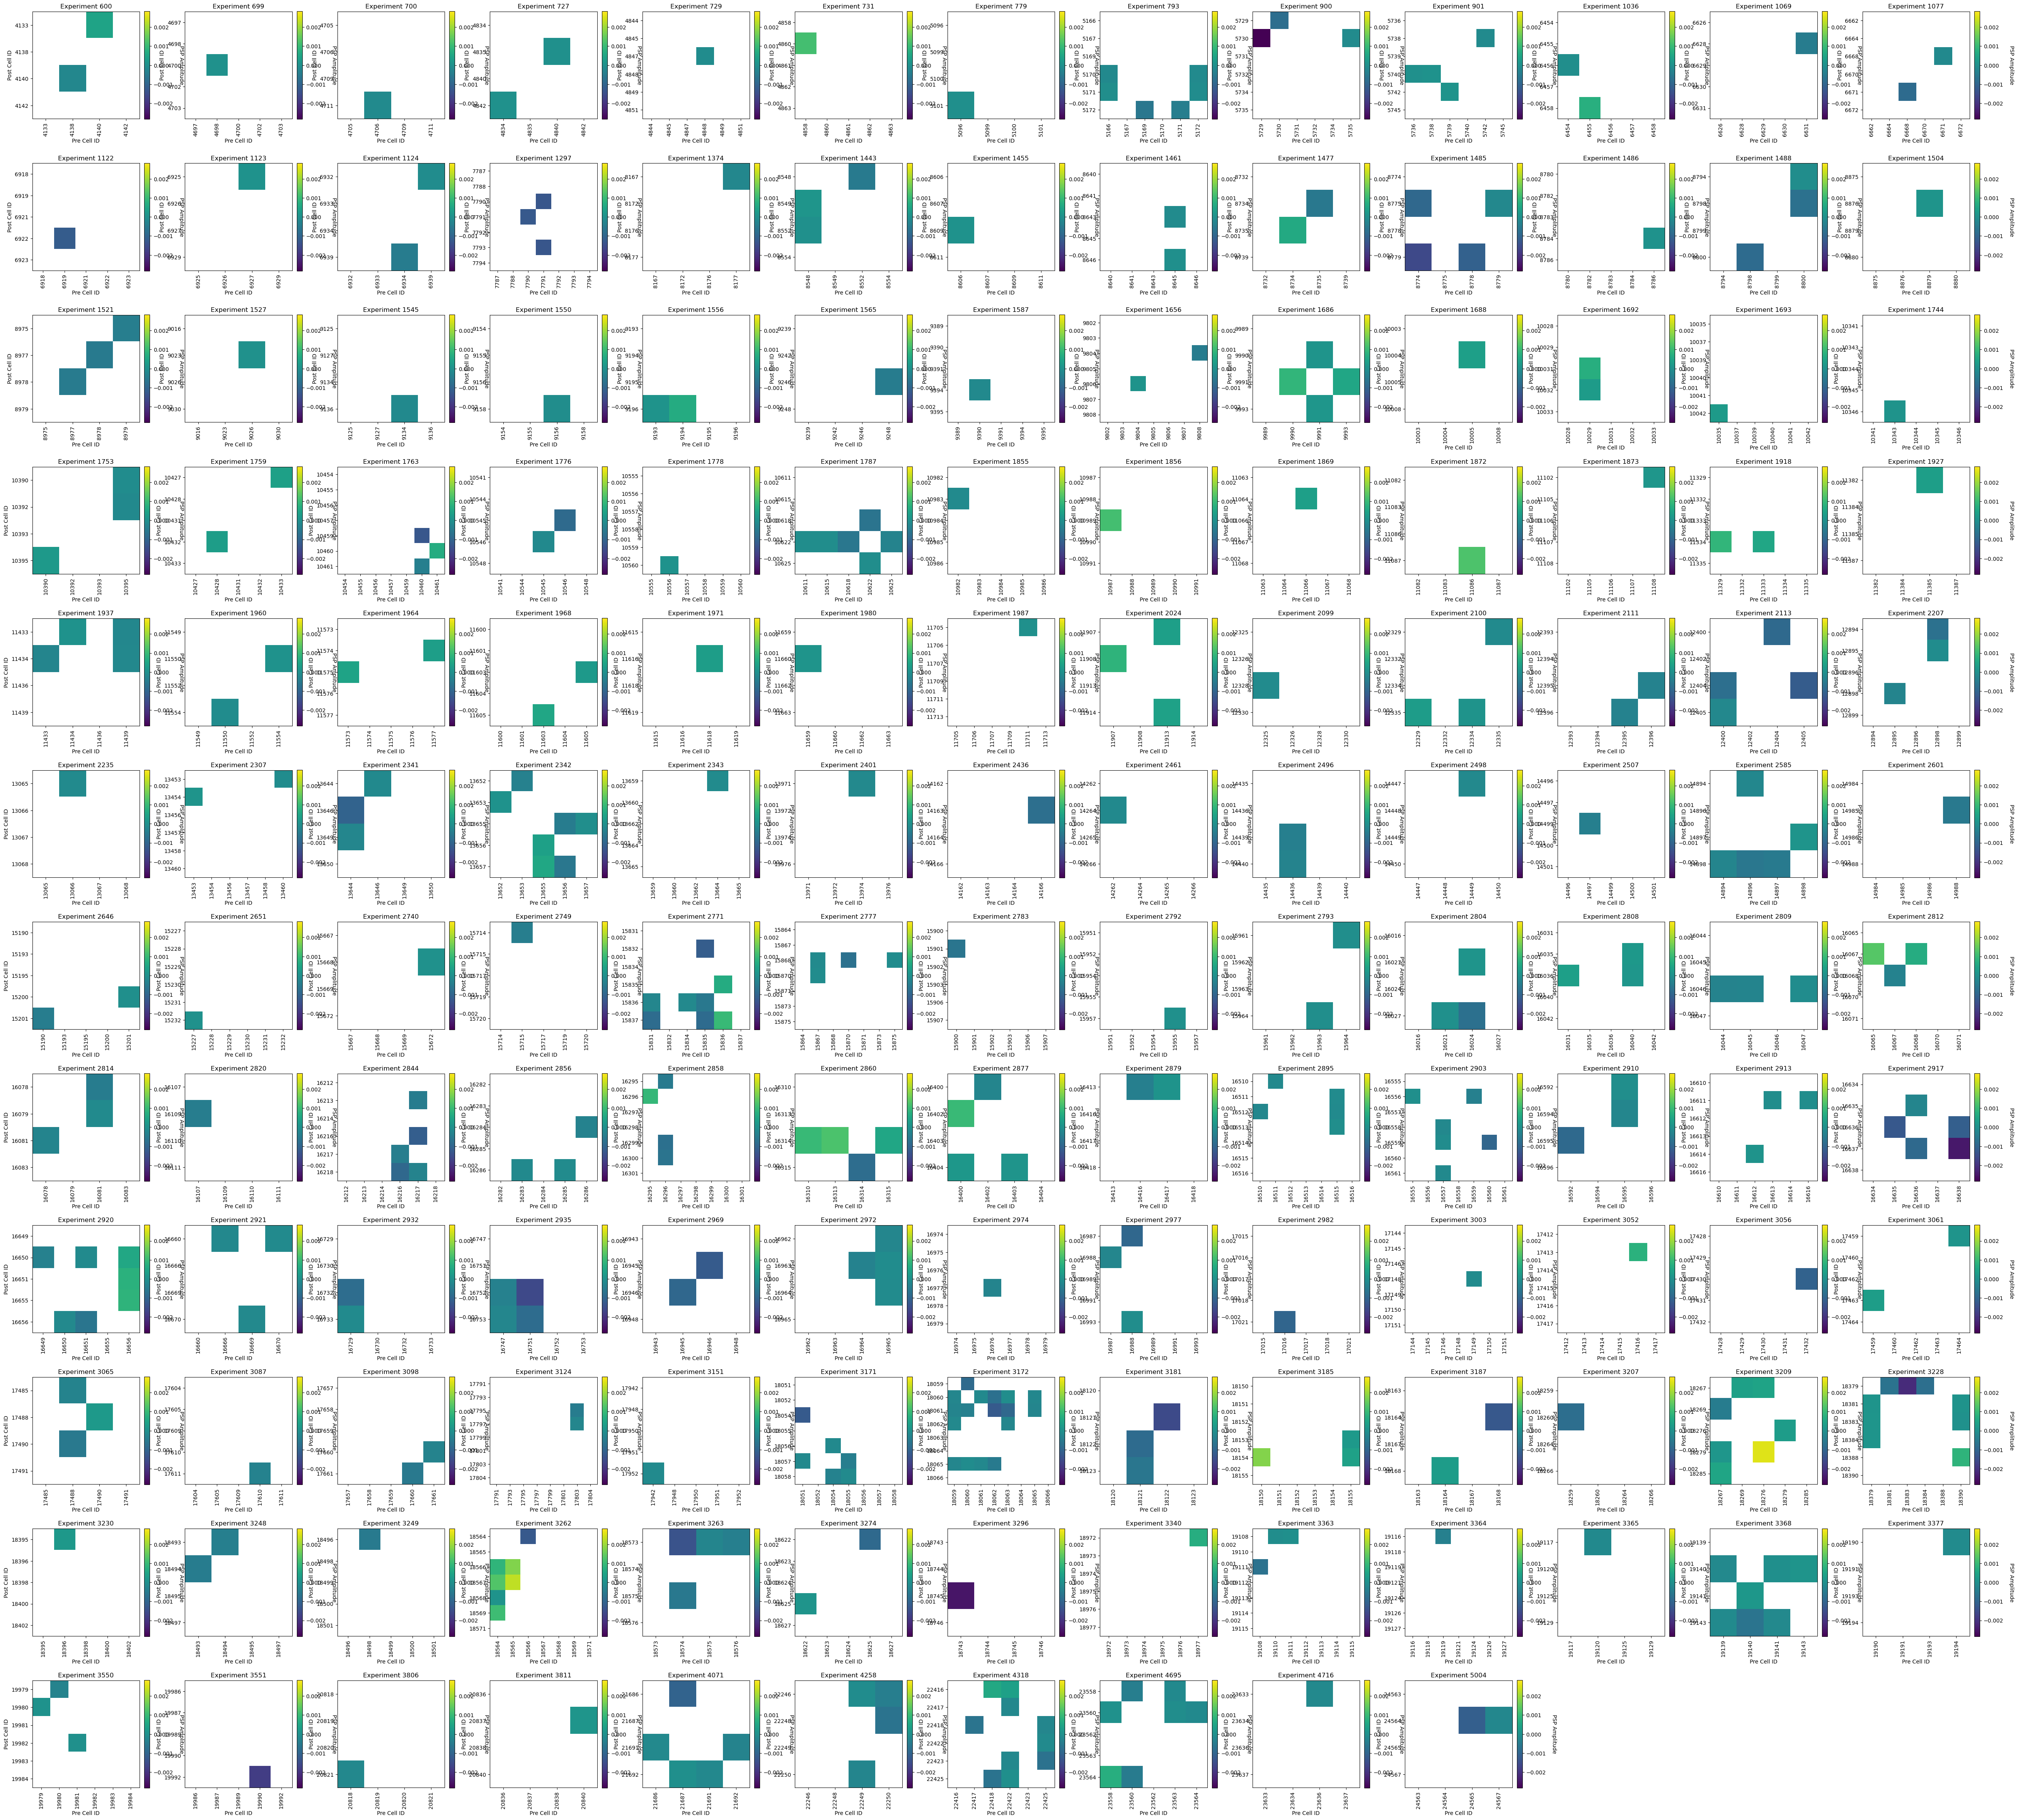

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Initialize containers
empty_experiments = {}  # those that had no synapses
non_empty_experiments = {}  # those that had something
considered_experiments = []  # List of considered experiments

# Load preprocessed data
df_result = pd.read_csv("preprocessed_data.csv")

# --------------------------------------------------

# Loop through all experiments and add to the list those with more than 10 data points

considered_experiments = [
    eid for eid in df['experiment_id'].unique()
    if (df['experiment_id'] == eid).sum() >= 10
]

# --------------------------------------------------

# Number of subplots based on number of data points
n_experiments = len(considered_experiments)
max_abs_psp = 0.0   # start with a neutral zero


# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")

for experiment_id in considered_experiments:  # Loop through only experiments with > k data points 

    df_experiment = df_result[df_result['experiment_id'] == experiment_id]   # Get ID
    all_cells = np.sort(pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel()))  # Get cells
    df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)  # Initialize dataframe of size (all_cells, all_cells)

    # --------------------------------------------------

    # PSP MATRIX

    for _, row in df_experiment.iterrows():  # Fill dataframe with PSP amplitude values for the synapses between pre- and postsynaptic cell
        pre_cell = row['pre_cell_id']
        post_cell = row['post_cell_id']
        psp_value = row['psp_amplitude']
        df_psp_matrix.loc[pre_cell, post_cell] = psp_value


    # Transpose matrix to get (post, pre)
    df_psp_matrix = df_psp_matrix.T

    # psp_matrix_numpy = df_psp_matrix.values  # get in numpy values, but not anymore the preferred way
    psp_matrix_numpy = df_psp_matrix.to_numpy()  # get in numpy values, becomes shape (n_cells, n_cells)

    # --------------------------------------------------

    # If empty, save in the empty list. Do not plot
    if np.all(np.isnan(df_psp_matrix.values)):
        empty_experiments[experiment_id] = (df_psp_matrix, df_psp_matrix.index.values)
        continue

    # If not empty, save in other list
    non_empty_experiments[experiment_id] = (df_psp_matrix, df_psp_matrix.index.values)

    # --------------------------------------------------

    # Update global color limit
    # Unsafe part:
    # max_abs_psp = max(max_abs_psp, np.nanmax(np.abs(psp_matrix_numpy)))  # Update maximum value
    # An alternative is:
    cur_max = np.nanmax(np.abs(psp_matrix_numpy))
    if not np.isnan(cur_max):
        max_abs_psp = max(max_abs_psp, cur_max)  # now max_abs_psp stays at 0 if there is no numeric data, which makes vmin=vmax=0 a valid, blank point


# # --------------------------------------------------


# # Loop through each considered experiment
# for i, experiment_id in enumerate(considered_experiments):
#     df_experiment = df_result[df_result['experiment_id'] == experiment_id]
    
#     # Generate PSP matrix for the experiment
#     all_cells = np.sort(pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel()))
#     df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)

#     for _, row in df_experiment.iterrows():
#         pre_cell = row['pre_cell_id']
#         post_cell = row['post_cell_id']
#         psp_value = row['psp_amplitude']
#         df_psp_matrix.loc[pre_cell, post_cell] = psp_value

#     psp_matrix_numpy = df_psp_matrix.values


# -------------------------------------------------
# Layout of sub‑plots (grid based on number of *plottable* experiments)
n_exps = len(non_empty_experiments)
n_cols = int(np.ceil(np.sqrt(n_exps)))
n_rows = int(np.ceil(n_exps / n_cols))

fig = plt.figure(figsize=(5 * n_cols, 5 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, wspace=0.3, hspace=0.3)

axes = [fig.add_subplot(gs[i // n_cols, i % n_cols]) for i in range(n_exps)]

# -------------------------------------------------

# Information statements
print(f"Non-empty experiments to plot: {len(non_empty_experiments)}")
print(f"Empty experiments (all NaN): {len(empty_experiments)}")
if len(empty_experiments):
    print(f"     Skipped IDs: {list(empty_experiments.keys())}")
# -------------------------------------------------

# Plot each stored matrix
num_plottable = len(non_empty_experiments)
if num_plottable == 0:
    print("No non-empty matrices.")
else:
    for i, (experiment_id, (psp_mat, cells)) in enumerate(non_empty_experiments.items()):
        # Create a mask for NaN values
        masked_psp_matrix = np.ma.masked_invalid(psp_mat.to_numpy())

        # Plot PSP matrix in corresponding subplot
        im = axes[i].imshow(masked_psp_matrix, cmap='viridis', interpolation='none', vmin=-max_abs_psp, vmax=max_abs_psp)
        axes[i].set_title(f'Experiment {experiment_id}')
        
        # Set tick labels with pre_cell_id and post_cell_id values
        axes[i].set_xticks(np.arange(len(cells)))
        axes[i].set_yticks(np.arange(len(cells)))
        axes[i].set_xticklabels(cells, rotation=90)
        axes[i].set_yticklabels(cells)
        axes[i].set_xlabel('Pre Cell ID')
        axes[i].set_ylabel('Post Cell ID')

        # Create colorbar with same size as subplot
        cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
        # Rotate colorbar title 180 degrees
        cbar.set_label('PSP Amplitude', rotation=270, labelpad=20)

    # Remove empty axes if there are fewer experiments than subplots
    for j in range(num_plottable, len(axes)):
        axes[j].axis('off')


    # Adjust subplots
    plt.tight_layout()
    plt.savefig('psp_matrix.png')
    plt.show()



In [12]:
# Compute motifs on the experiments

def safe_divide(n, d):
    # Devuelve np.nan si el denominador es cero
    # Returns np.nan if the denominator is zero
    # Convert to np.ndarray (no copy if already an array)

    return n / d if d != 0 else np.nan


def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.nanmean(w)  # centre matrix using nanmean (ignore NaN)
   w = np.nan_to_num(w, nan=0.0)  # any NaN left become zero


   ww=np.matmul(w,w)        # w*w
   wtw=np.matmul(w.T,w)     # w^T * w
   wwt=np.matmul(w,w.T)     # w * w^T

   # sigma^2
   sigma2=np.trace(wwt)/N


   # Reciprocal
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N

   # Divergent
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)

   # Convergent
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)

   # Chain
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)

   return tau_rec,tau_div,tau_con,tau_chn

motif_results = []  # List that contains dictionaries
nan_motif_experiments = []

for exp_id, (psp_df, cells) in non_empty_experiments.items():
   w = psp_df.to_numpy ()  # convert dataframe to dense numpy (square, shape (N, N)
   N = w.shape[0]  # number of neurons
   print(exp_id)
   tau_rec, tau_div, tau_con, tau_chn = motifs(w, N)
   if np.isnan([tau_rec, tau_div, tau_con, tau_chn]).any():
    nan_motif_experiments.append(exp_id)
   

   # Store in dict
   motif_results.append({
        "experiment_id": exp_id,
        "N_neurons"    : N,
        "tau_rec"      : tau_rec,
        "tau_div"      : tau_div,
        "tau_con"      : tau_con,
        "tau_chn"      : tau_chn
    })

motif_df = pd.DataFrame(motif_results)

print("\nMotif statistics for every plotted experiment:")
# print(motif_df)

# motif_df_noallnan = motif_df[motif_df[]]

# (optional) write to CSV
motif_df.to_csv("experiment_motifs.csv", index=False)

600
699
700
727
729
731
779
793
900
901
1036
1069
1077
1122
1123
1124
1297
1374
1443
1455
1461
1477
1485
1486
1488
1504
1521
1527
1545
1550
1556
1565
1587
1656
1686
1688
1692
1693
1744
1753
1759
1763
1776
1778
1787
1855
1856
1869
1872
1873
1918
1927
1937
1960
1964
1968
1971
1980
1987
2024
2099
2100
2111
2113
2207
2235
2307
2341
2342
2343
2401
2436
2461
2496
2498
2507
2585
2601
2646
2651
2740
2749
2771
2777
2783
2792
2793
2804
2808
2809
2812
2814
2820
2844
2856
2858
2860
2877
2879
2895
2903
2910
2913
2917
2920
2921
2932
2935
2969
2972
2974
2977
2982
3003
3052
3056
3061
3065
3087
3098
3124
3151
3171
3172
3181
3185
3187
3207
3209
3228
3230
3248
3249
3262
3263
3274
3296
3340
3363
3364
3365
3368
3377
3550
3551
3806
3811
4071
4258
4318
4695
4716
5004

Motif statistics for every plotted experiment:


C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\524793158.py:30: RuntimeWarning: invalid value encountered in scalar divide
  tau_rec/=sigma2*N
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\524793158.py:34: RuntimeWarning: invalid value encountered in scalar divide
  tau_div/=sigma2*N*(N-1)
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\524793158.py:38: RuntimeWarning: invalid value encountered in scalar divide
  tau_con/=sigma2*N*(N-1)
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\524793158.py:42: RuntimeWarning: invalid value encountered in scalar divide
  tau_chn/=sigma2*N*(N-1)


In [14]:
motif_df

,experiment_id,N_neurons,tau_rec,tau_div,tau_con,tau_chn
0,600,4,0.000000,0.000000,0.000000,-0.333333
1,699,5,NaN,NaN,NaN,NaN
2,700,4,NaN,NaN,NaN,NaN
3,727,4,0.000000,0.000000,0.000000,0.000000
4,729,6,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
148,4258,4,0.000000,0.142695,-0.043703,-0.122740
149,4318,6,0.042965,-0.071641,0.088350,0.000708
150,4695,5,-0.002962,0.119731,-0.165384,-0.224025
151,4716,4,NaN,NaN,NaN,NaN


[np.int64(699), np.int64(700), np.int64(729), np.int64(731), np.int64(779), np.int64(1069), np.int64(1122), np.int64(1123), np.int64(1374), np.int64(1455), np.int64(1486), np.int64(1504), np.int64(1527), np.int64(1545), np.int64(1550), np.int64(1565), np.int64(1587), np.int64(1688), np.int64(1693), np.int64(1744), np.int64(1778), np.int64(1855), np.int64(1856), np.int64(1869), np.int64(1872), np.int64(1873), np.int64(1927), np.int64(1971), np.int64(1980), np.int64(1987), np.int64(2099), np.int64(2235), np.int64(2343), np.int64(2401), np.int64(2436), np.int64(2461), np.int64(2498), np.int64(2507), np.int64(2601), np.int64(2651), np.int64(2740), np.int64(2749), np.int64(2783), np.int64(2792), np.int64(2820), np.int64(2974), np.int64(2982), np.int64(3003), np.int64(3052), np.int64(3056), np.int64(3087), np.int64(3151), np.int64(3207), np.int64(3230), np.int64(3249), np.int64(3296), np.int64(3340), np.int64(3364), np.int64(3365), np.int64(3377), np.int64(3551), np.int64(3806), np.int64(381

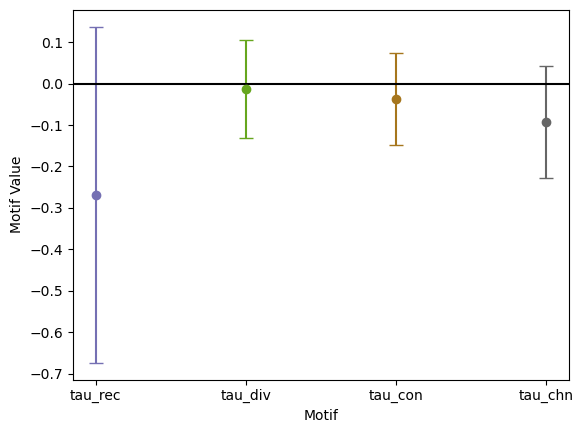

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))






print(nan_motif_experiments)

mask = motif_df["experiment_id"].isin(nan_motif_experiments)

df_clean = motif_df[~mask].reset_index(drop=True)  # drop the ones in mask, and keep rows we want

taus = ['tau_rec', 'tau_div', 'tau_con', 'tau_chn']
color_map_motif = make_color_map(taus, plt.cm.Dark2)  # color map

fig, ax = plt.subplots()

for i, t in enumerate(taus):
    current_motif = df_clean[t]

    mean = current_motif.mean()
    std = current_motif.std()

    ax.errorbar(i, mean, yerr=std, capsize=5, fmt='o', color=color_map_motif[t])

ax.set_xticks([i for i in range(4)], taus)
ax.axhline(0, color='black')
# ax.set_title("Motif values")
ax.set_ylabel("Motif Value")
ax.set_xlabel("Motif")

plt.show()



In [ ]:
import pandas as pd
file = pd.read_csv("preprocessed_data.csv")
df = file.copy()

df = df[(df['fi_slope_post']>= 0) & (df['fi_slope_pre'] >= 0)]

df

# 'homogenous
II = df[(df['pre_cell_class']=='in') & (df['post_cell_class']=='in')]
EE = df[(df['pre_cell_class']=='ex') & (df['post_cell_class']=='ex')]
MM = df[(df['pre_cell_class']=='mixed') & (df['post_cell_class']=='mixed')]

# 'heterogenous'

EI = df[(df['pre_cell_class']=='ex') & (df['post_cell_class']=='in')]
EM = df[(df['pre_cell_class'] == 'ex') & (df['post_cell_class'] == 'mixed')]

IE = df[(df['pre_cell_class']=='in') & (df['post_cell_class']=='ex')]
IM = df[(df['pre_cell_class'] == 'in') & (df['post_cell_class'] == 'mixed')]


ME = df[(df['pre_cell_class'] == 'mixed') & (df['post_cell_class'] == 'ex')]
MI = df[(df['pre_cell_class'] == 'mixed') & (df['post_cell_class'] == 'in')]



for df, name in zip([II, EE, MM, EI, EM, IE, IM, ME, MI], ['II', 'EE', 'MM', 'EI', 'EM', 'IE', 'IM', 'ME', 'MI']):
    print(f"Number of entries for {name}: {len(df)}")


classes = ['ex', 'in', 'mixed']
pairwise = {}

for pre in classes:
    for post in classes:
        key = f'{pre[0].upper()}{post[0].upper()}'   # e.g. 'EI', 'MM', …
        pairwise[key] = df[(df['pre_cell_class'] == pre) &
                           (df['post_cell_class'] == post)]

# Example: access the "mixed → ex" dataframe
ME = pairwise['ME']




Number of entries for II: 2985
Number of entries for EE: 1365
Number of entries for MM: 24
Number of entries for EI: 757
Number of entries for EM: 53
Number of entries for IE: 758
Number of entries for IM: 114
Number of entries for ME: 53
Number of entries for MI: 115


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,psp_amplitude
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,NaN
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,NaN
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,NaN
5,600,4138,4142,0,in,in,1.105000e-12,8.820777e-13,NaN
9,600,4142,4133,0,in,in,8.820777e-13,8.230065e-13,NaN
...,...,...,...,...,...,...,...,...,...
7965,5022,24614,24617,0,in,in,7.524247e-13,1.946527e-13,NaN
7966,5022,24615,24614,1,in,in,6.317902e-13,7.524247e-13,NaN
7967,5022,24615,24617,0,in,in,6.317902e-13,1.946527e-13,NaN
7968,5022,24617,24614,0,in,in,1.946527e-13,7.524247e-13,NaN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compute motifs on the experiments

def safe_divide(n, d):
    # Devuelve np.nan si el denominador es cero
    # Returns np.nan if the denominator is zero
    # Convert to np.ndarray (no copy if already an array)

    return n / d if d != 0 else np.nan


def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.nanmean(w)  # centre matrix using nanmean (ignore NaN)
   w = np.nan_to_num(w, nan=0.0)  # any NaN left become zero


   ww=np.matmul(w,w)        # w*w
   wtw=np.matmul(w.T,w)     # w^T * w
   wwt=np.matmul(w,w.T)     # w * w^T

   # sigma^2
   sigma2=np.trace(wwt)/N


   # Reciprocal
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N

   # Divergent
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)

   # Convergent
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)

   # Chain
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)

   return tau_rec,tau_div,tau_con,tau_chn



# --------------------------------------------------
# Initialize containers
empty_experiments = {}  # those that had no synapses
non_empty_experiments = {}  # those that had something
considered_experiments = []  # List of considered experiments
motif_results = []  # List that contains dictionaries
nan_motif_experiments = []
motif_by_class = []          # each element will become ONE ROW in the final DF
nan_experiments = []         # keep track of experiments that yield NaNs

# Load preprocessed data
df_result = pd.read_csv("preprocessed_data.csv")

# --------------------------------------------------

# Loop through all experiments and add to the list those with more than 10 data points

num_syn = 2
considered_experiments = [
    eid for eid in df['experiment_id'].unique()
    if (df['experiment_id'] == eid).sum() >= num_syn
]

print(f"Keeping {len(considered_experiments)} experiments ( >= {num_syn} synapses)")

# --------------------------------------------------
# Cell classes

classes = ['ex', 'in', 'mixed']
pairwise = {}

for pre in classes:
    for post in classes:
        key = f'{pre[0].upper()}{post[0].upper()}'   # e.g. 'EI', 'MM', …
        pairwise[key] = df[(df['pre_cell_class'] == pre) &
                           (df['post_cell_class'] == post)]

pairwise_keys = [f"{pre[0].upper()}{post[0].upper()}"
                 for pre in classes for post in classes]   # ['EE','EI',…,'MM']
# --------------------------------------------------

# Number of subplots based on number of data points
n_experiments = len(considered_experiments)
max_abs_psp = 0.0   # start with a neutral zero


# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")



Keeping 28 experiments ( >= 2 synapses)


Loaded 878 distinct experiments with a total of 7978 synaptic records.

Keeping 876 experiments (>= 2 synapses).

Progress: 100/7884 (1.3% ) - exp 654, pair EE
Progress: 200/7884 (2.5% ) - exp 732, pair EI
Progress: 300/7884 (3.8% ) - exp 825, pair EM
Progress: 400/7884 (5.1% ) - exp 900, pair IE
Progress: 500/7884 (6.3% ) - exp 1046, pair II
Progress: 600/7884 (7.6% ) - exp 1119, pair IM
Progress: 700/7884 (8.9% ) - exp 1201, pair ME
Progress: 800/7884 (10.1% ) - exp 1305, pair MI
Progress: 900/7884 (11.4% ) - exp 1378, pair MM
Progress: 1000/7884 (12.7% ) - exp 1442, pair EE
Progress: 1100/7884 (14.0% ) - exp 1472, pair EI
Progress: 1200/7884 (15.2% ) - exp 1488, pair EM
Progress: 1300/7884 (16.5% ) - exp 1512, pair IE
Progress: 1400/7884 (17.8% ) - exp 1530, pair II
Progress: 1500/7884 (19.0% ) - exp 1551, pair IM
Progress: 1600/7884 (20.3% ) - exp 1577, pair ME
Progress: 1700/7884 (21.6% ) - exp 1602, pair MI
Progress: 1800/7884 (22.8% ) - exp 1635, pair MM
Progress: 1900/7884 (24.

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3148645005.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in motif_by_class_df.groupby('class_pair')[motif_to_plot]]
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3148645005.py:245: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,


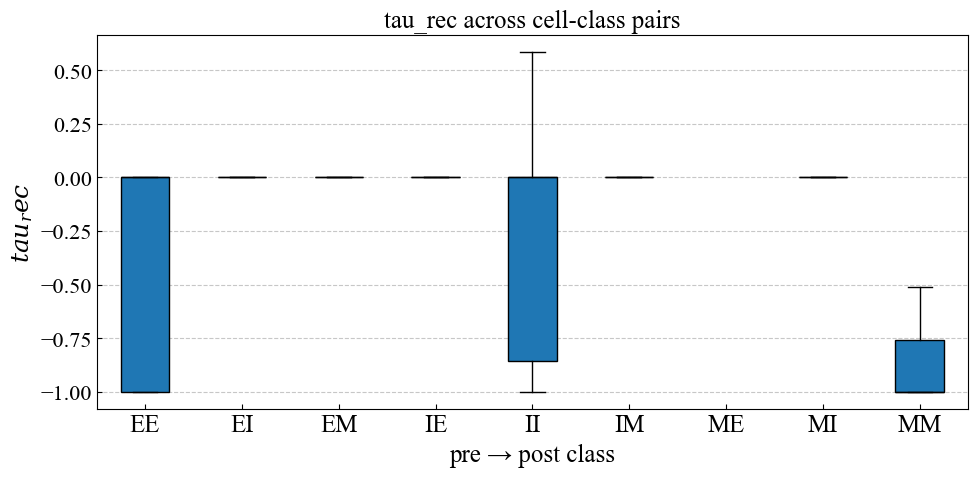


Saved tidy motif table to 'motif_by_class_results.csv'.


In [163]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Compute the four motifs (reciprocal, divergent, convergent, chain) for every experiment and for every pre→post cell class combination (EE, EI, EM, IE, II, IM, ME, MI, MM).

Output
------
motif_by_class_df : pandas.DataFrame
    Columns: experiment_id, class_pair, N_neurons,
             tau_rec, tau_div, tau_con, tau_chn
"""

# ----------------------------------------------------------------------

# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore", category=RuntimeWarning,
                        message="invalid value encountered in scalar divide")
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="Mean of empty slice")

# ----------------------------------------------------------------------

# Helper functions

def safe_divide(num, den):
    """Return np.nan when the denominator is zero."""
    return num / den if den != 0 else np.nan


def motifs(w, N):
    """
    Compute the motif scores from an (N * N) PSP matrix.

    Parameters
    ----------
    w : np.ndarray
        PSP matrix (may contain NaNs).
    N : int
        Number of neurons (matrix dimension).

    Returns
    -------
    tuple of float
        (tau_rec, tau_div, tau_con, tau_chn)
    """
    # centre the matrix (ignore NaNs) and replace remaining NaNs by 0
    w = w - np.nanmean(w)
    w = np.nan_to_num(w, nan=0.0)

    ww  = w @ w          # w * w
    wtw = w.T @ w        # wᵀ * w
    wwt = w @ w.T        # w * wᵀ

    sigma2 = np.trace(wwt) / N

    # Reciprocal
    tau_rec = np.trace(ww) / (sigma2 * N)

    # Divergent
    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    # Convergent
    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    # Chain
    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


# ----------------------------------------------------------------------

# Load the global synapse table

df = pd.read_csv("preprocessed_data.csv")

print(f"Loaded {df['experiment_id'].nunique()} distinct experiments "
      f"with a total of {len(df)} synaptic records.\n")


# ----------------------------------------------------------------------

# Keep only experiments that have ≥ 2 synapses

considered_experiments = [
    eid for eid in df['experiment_id'].unique()
    if (df['experiment_id'] == eid).sum() >= 2
]

print(f"Keeping {len(considered_experiments)} experiments (>= 2 synapses).\n")


# ----------------------------------------------------------------------

# Prepare the nine pre ---> post class‑pair keys

classes = ['ex', 'in', 'mixed']
pairwise_keys = [f"{pre[0].upper()}{post[0].upper()}"
                 for pre in classes for post in classes]   # ['EE','EI',…,'MM']

# Helper to translate single‑letter code back to full class name
letter_to_class = {'e': 'ex', 'i': 'in', 'm': 'mixed'}

# ----------------------------------------------------------------------

# Main loop: compute motifs for every experiment * class pair

motif_by_class = []      # list of dicts → will become a DataFrame
nan_experiments = []     # optional bookkeeping

total_iters = len(considered_experiments) * len(pairwise_keys)
counter = 0

for exp_id in considered_experiments:
    # --------------------------------------------------------------

    # Sub‑frame that belongs to the current experiment only

    df_exp = df[df['experiment_id'] == exp_id]

    # All distinct cells that appear in this experiment (same for all pairs)
    all_cells = np.sort(pd.unique(df_exp[['pre_cell_id',
                                          'post_cell_id']].values.ravel()))
    cell_index = {cid: i for i, cid in enumerate(all_cells)}
    n_cells = len(all_cells)

    # --------------------------------------------------------------

    # Loop over the nine class‑pair combinations

    for key in pairwise_keys:
        counter += 1
        # Simple textual progress (no tqdm)
        if counter % 100 == 0 or counter == total_iters:
            print(f"Progress: {counter}/{total_iters} "
                  f"({100.*counter/total_iters:.1f}% ) - exp {exp_id}, pair {key}")

        pre_full  = letter_to_class[key[0].lower()]   # e.g. 'E' → 'ex'
        post_full = letter_to_class[key[1].lower()]   # e.g. 'I' → 'in'

        # ----------------------------------------------------------
        
        # Sub‑frame that contains only synapses of this class pair

        df_pair = df_exp[
            (df_exp['pre_cell_class']  == pre_full) &
            (df_exp['post_cell_class'] == post_full)
        ]

        # If there are *no* connections for this pair we still write a row with NaNs (so the final table stays rectangular)
        if df_pair.empty:
            motif_by_class.append({
                "experiment_id": exp_id,
                "class_pair"   : key,
                "N_neurons"    : n_cells,
                "tau_rec"      : np.nan,
                "tau_div"      : np.nan,
                "tau_con"      : np.nan,
                "tau_chn"      : np.nan
            })
            continue

        # ----------------------------------------------------------

        # Build the PSP matrix for this pair
        #   – rows correspond to post‑synaptic cells 

        mat = np.full((n_cells, n_cells), np.nan, dtype=float)

        for _, row in df_pair.iterrows():
            i = cell_index[row['pre_cell_id']]
            j = cell_index[row['post_cell_id']]
            mat[i, j] = row['psp_amplitude']

        mat = mat.T   # transpose so that rows = post, cols = pre

        # ----------------------------------------------------------

        # Compute the four motif scores

        tau_rec, tau_div, tau_con, tau_chn = motifs(mat, n_cells)

        if np.isnan([tau_rec, tau_div, tau_con, tau_chn]).any():
            nan_experiments.append(exp_id)

        # ----------------------------------------------------------

        # Store the result

        motif_by_class.append({
            "experiment_id": exp_id,
            "class_pair"   : key,
            "N_neurons"    : n_cells,
            "tau_rec"      : tau_rec,
            "tau_div"      : tau_div,
            "tau_con"      : tau_con,
            "tau_chn"      : tau_chn
        })

print("\nFinished motif calculations.\n")
if nan_experiments:
    print(f"Warning: {len(set(nan_experiments))} experiments produced NaN "
          f"motif values.\n")


# ----------------------------------------------------------------------

# Assemble final tidy DataFrame

motif_by_class_df = pd.DataFrame(motif_by_class)

# Make the class‑pair column an ordered categorical (nice for plotting)
ordered_keys = ['EE', 'EI', 'EM', 'IE', 'II', 'IM', 'ME', 'MI', 'MM']
motif_by_class_df['class_pair'] = pd.Categorical(
    motif_by_class_df['class_pair'],
    categories=ordered_keys,
    ordered=True
)

# print("Result preview (first 10 rows):")
# print(motif_by_class_df.head(10))


# ----------------------------------------------------------------------
#visual 

# Choose which motif to plot
motif_to_plot = "tau_rec"          # other options: "tau_div", "tau_con", "tau_chn"

# Drop NaNs for the box‑plot (Matplotlib will ignore them automatically)
plot_data = [group.dropna().values
             for _, group in motif_by_class_df.groupby('class_pair')[motif_to_plot]]

plt.figure(figsize=(10, 5))
plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,
            medianprops=dict(color='black'))

plt.title(f"{motif_to_plot} across cell‑class pairs")
plt.xlabel("pre → post class")
plt.ylabel(rf"${{{motif_to_plot}}}$")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------

# Save the results 

motif_by_class_df.to_csv("motif_by_class_results.csv", index=False)
print("\nSaved tidy motif table to 'motif_by_class_results.csv'.")


['EE' 'EI' 'EM' 'IE' 'II' 'IM' 'ME' 'MI' 'MM']


TypeError: Could not convert ['EEEEEEEEEE'] to numeric

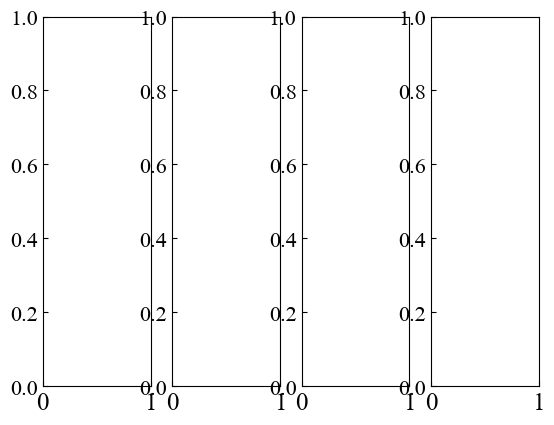

In [178]:
dfMotif = pd.read_csv("motif_by_class_results.csv")

dfMotif

df = pd.read_csv('motif_by_class_results.csv')

# df_nonan = df.dropna(subset=['tau_rec', 'tau_div', 'tau_con', 'tau_chn'])

# df_nonan


# display(df_nonan[(df_nonan['class_pair']=='II')])


classes = df["class_pair"].unique()

print(classes)

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

fig, axs = plt.subplots(nrows=1, ncols=len(motifs))
for i, m in enumerate(motifs):
    ax = axs[i]

    means = []
    stds = []
    for pair in classes:
        df_filtered = df[(df["class_pair"]==pair) & (df[m])].dropna()

        mean = df_filtered.mean()
        std = df_filtered.std()

        means.append(mean)
        stds.append(std)

    ax.errorbar(pair, means, yerr=stds, capsize=5, fmt='o')


plt.show()



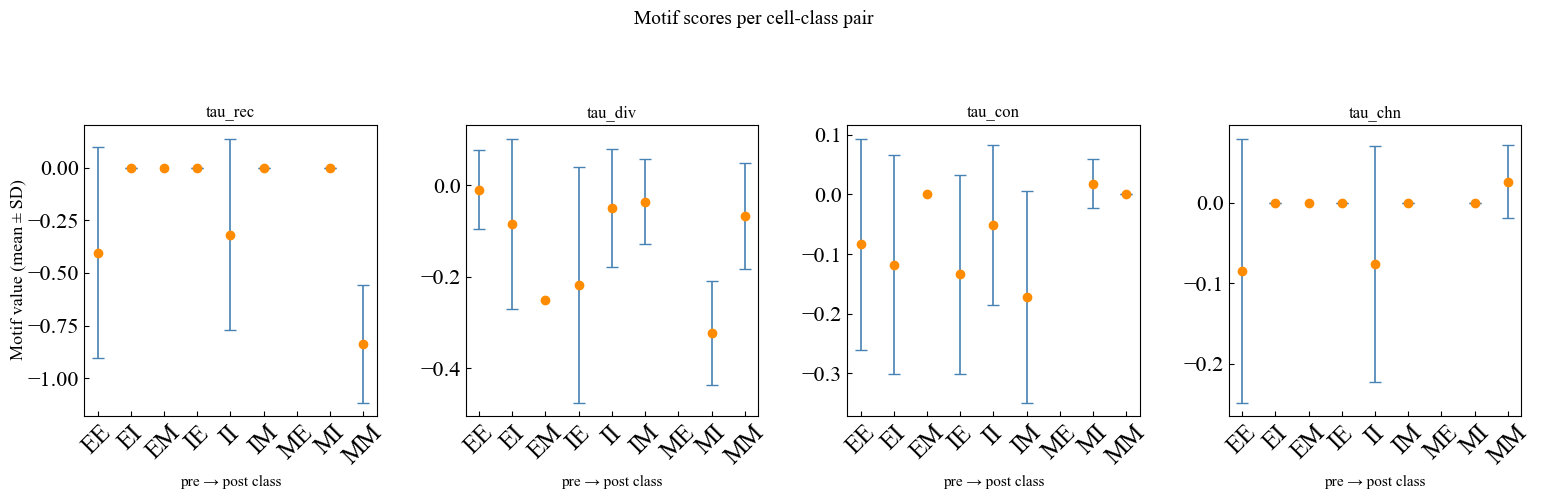

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------

# Load the results that were written by the previous script

df = pd.read_csv("motif_by_class_results.csv")

# ----------------------------------------------------------------------

# Order the class‑pair categories (so the x‑axis is always the same)

ordered_pairs = ['EE', 'EI', 'EM', 'IE', 'II', 'IM', 'ME', 'MI', 'MM']
df["class_pair"] = pd.Categorical(df["class_pair"],
                                  categories=ordered_pairs,
                                  ordered=True)

# ----------------------------------------------------------------------

# Set up the motifs we want to plot

motif_names = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
n_motifs    = len(motif_names)

# ----------------------------------------------------------------------

# Create one subplot per motif

fig, axs = plt.subplots(nrows=1, ncols=n_motifs, figsize=(4 * n_motifs, 5),
                        sharey=False)

# Loop over motifs ---------------------------------------------------------
for i, motif in enumerate(motif_names):
    ax = axs[i]

    # ------------------------------------------------------------------

    #   Compute mean ± SD for every class‑pair (ignore NaNs)

    means = []
    stds  = []
    for pair in ordered_pairs:
        # Select rows belonging to the current pair and drop NaNs in the motif column
        data = df.loc[(df["class_pair"] == pair), motif].dropna()

        # If a pair has no valid values we use NaN → the point will be omitted
        means.append(data.mean())
        stds.append(data.std())

    # ------------------------------------------------------------------

    #   Plot error‑bars

    ax.errorbar(ordered_pairs, means, yerr=stds,
                fmt='o', capsize=4, ecolor='steelblue',
                color='darkorange', markersize=6, linewidth=1.2)

    ax.set_title(motif, fontsize=12)
    ax.set_xlabel("pre → post class", fontsize=11)
    ax.tick_params(axis='x', rotation=45)


# ----------------------------------------------------------------------

# Common y‑label and overall layout

fig.text(0.04, 0.5, "Motif value (mean ± SD)", va='center', ha='center',
         rotation='vertical', fontsize=13)
fig.suptitle("Motif scores per cell‑class pair", fontsize=14, y=1.02)
fig.tight_layout(rect=[0.04, 0.02, 1.00, 0.95])

plt.show()


C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in motif_by_class_df.groupby('class_pair')[m]]
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,


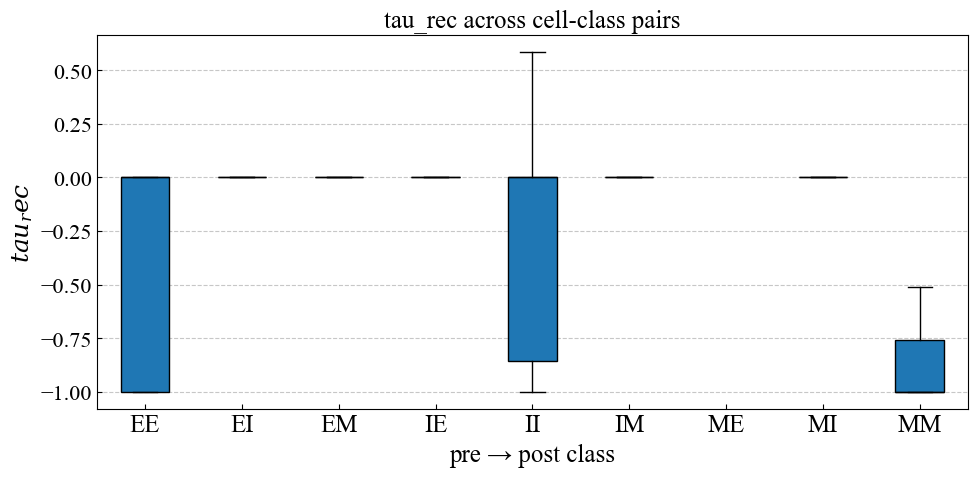

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in motif_by_class_df.groupby('class_pair')[m]]
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,


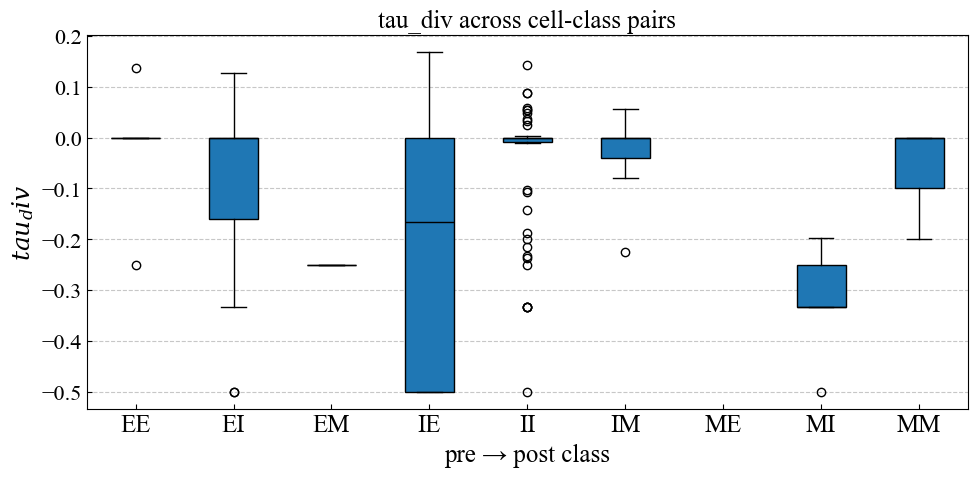

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in motif_by_class_df.groupby('class_pair')[m]]
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,


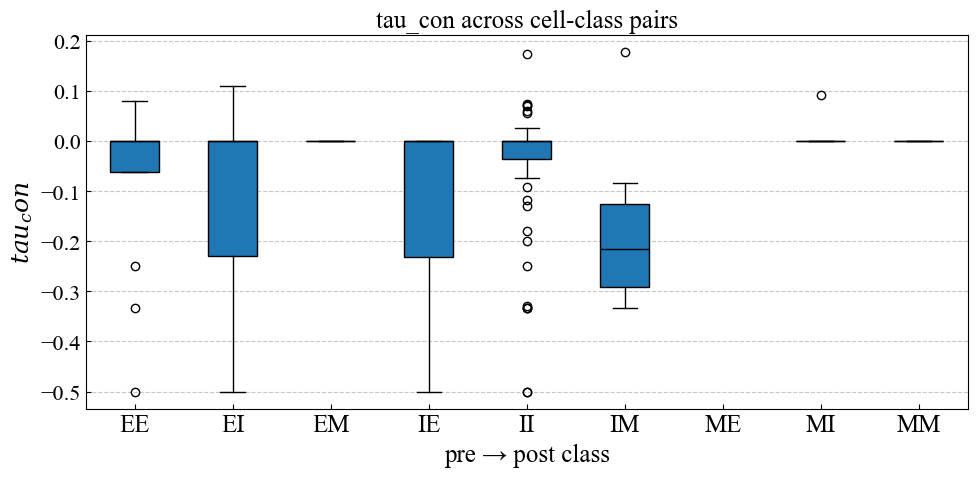

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in motif_by_class_df.groupby('class_pair')[m]]
C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3885004304.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,


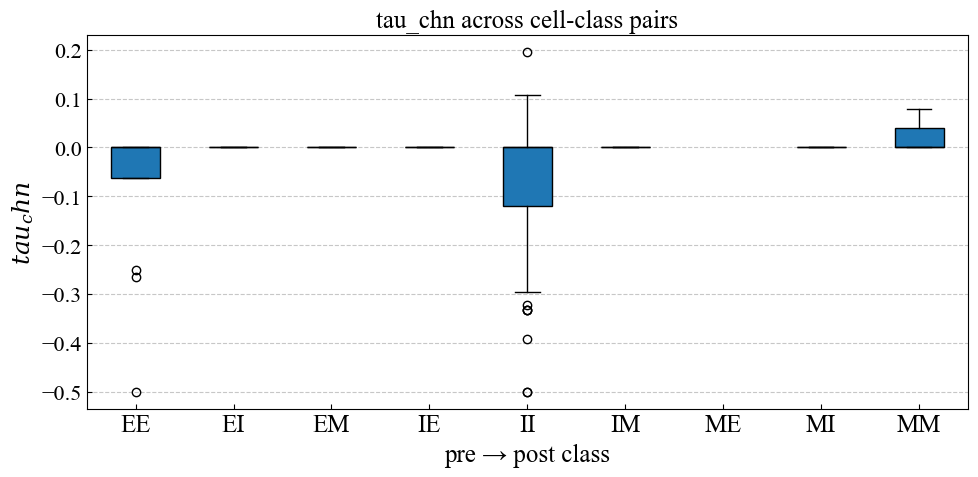

In [ ]:
# ----------------------------------------------------------------------
#visual 

# Choose which motif to plot
motif_to_plot = "tau_rec"          # other options: "tau_div", "tau_con", "tau_chn"
motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

for m in motifs:

    # Drop NaNs for the box‑plot (Matplotlib will ignore them automatically)
    plot_data = [group.dropna().values
                for _, group in motif_by_class_df.groupby('class_pair')[m]]

    plt.figure(figsize=(10, 5))
    plt.boxplot(plot_data, labels=ordered_keys, patch_artist=True,
                medianprops=dict(color='black'))

    plt.title(f"{m} across cell‑class pairs")
    plt.xlabel("pre → post class")
    plt.ylabel(rf"${{{m}}}$")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


for m in motifs:
    data = df


# ----------------------------------------------------------------------

# Save the results 

# motif_by_class_df.to_csv("motif_by_class_results.csv", index=False)
# print("\nSaved tidy motif table to 'motif_by_class_results.csv'.")

In [169]:
df = pd.read_csv('motif_by_class_results.csv')

df_nonan = df.dropna(subset=['tau_rec', 'tau_div', 'tau_con', 'tau_chn'])

df_nonan


display(df_nonan[(df_nonan['class_pair']=='II')])

,experiment_id,class_pair,N_neurons,tau_rec,tau_div,tau_con,tau_chn
265,793,II,6,-0.230875,5.423597e-02,0.173481,-0.250175
400,900,II,6,-0.357037,0.000000e+00,-0.179693,0.051101
535,1077,II,6,-1.000000,0.000000e+00,0.000000,0.000000
634,1124,II,4,0.000000,0.000000e+00,0.000000,-0.333333
760,1260,II,2,-1.000000,0.000000e+00,0.000000,0.000000
778,1297,II,7,-0.735664,5.469858e-02,0.000000,-0.098755
994,1436,II,3,0.000000,0.000000e+00,-0.500000,0.000000
1066,1461,II,5,0.000000,-2.500000e-01,0.000000,0.000000
1174,1485,II,4,0.000000,-1.045146e-02,0.071741,-0.392351
1201,1488,II,4,-1.000000,0.000000e+00,0.000000,0.000000


# Attempt to divide into fi slopes as well

In [87]:
df_result = pd.read_csv("preprocessed_data_categorized.csv")

df_result


# print(categories)


df_result_noneg = df_result[df_result['category'] != 'negative']
categories = df_result_noneg["category"].unique().tolist()
# categories = ['small', 'medium', 'high', 'very_high']

df_result_noneg

print(categories)

['small', 'medium', 'high', 'very_high']


No experiments with sufficient data were found.

=== Motif statistics (experiment × FI‑category) ===
Empty DataFrame
Columns: []
Index: []


KeyError: 'category'

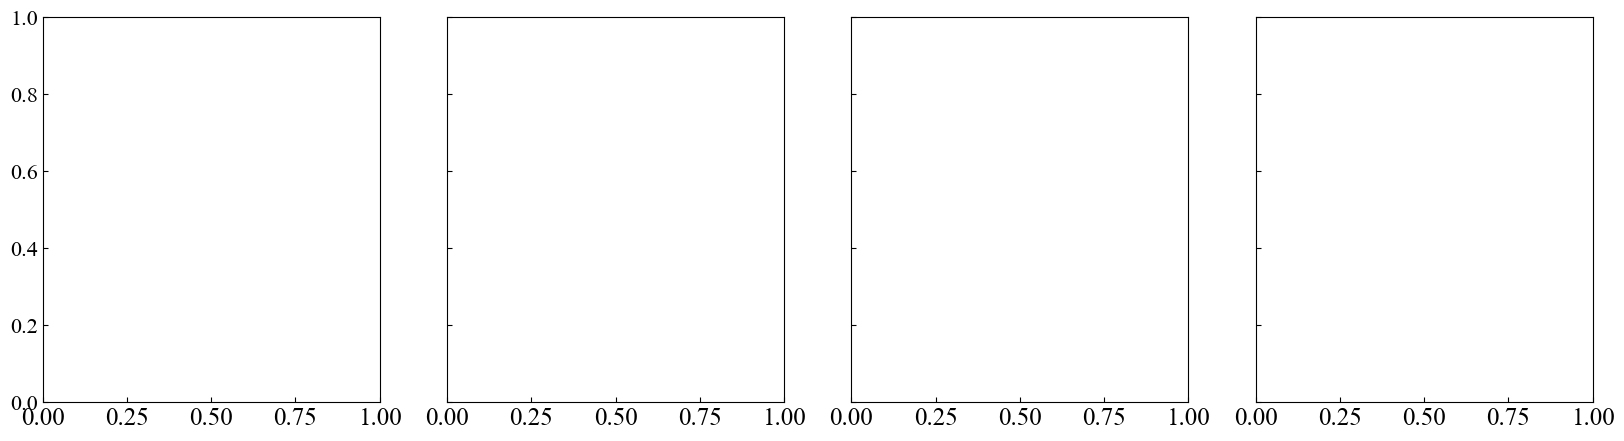

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compute motifs on the experiments

def safe_divide(n, d):
    # Devuelve np.nan si el denominador es cero
    # Returns np.nan if the denominator is zero
    # Convert to np.ndarray (no copy if already an array)

    return n / d if d != 0 else np.nan


def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.nanmean(w)  # centre matrix using nanmean (ignore NaN)
   w = np.nan_to_num(w, nan=0.0)  # any NaN left become zero


   ww=np.matmul(w,w)        # w*w
   wtw=np.matmul(w.T,w)     # w^T * w
   wwt=np.matmul(w,w.T)     # w * w^T

   # sigma^2
   sigma2=np.trace(wwt)/N


   # Reciprocal
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N

   # Divergent
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)

   # Convergent
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)

   # Chain
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)

   return tau_rec,tau_div,tau_con,tau_chn

# --------------------------------------------------
# Initialize containers
empty_experiments = {}  # those that had no synapses
non_empty_experiments = {}  # those that had something
considered_experiments = []  # List of considered experiments
motif_by_cat = []

# Load preprocessed data
df_temp = pd.read_csv("preprocessed_data_categorized.csv")
df_result = df_temp[df_temp['category'] != 'negative']  # dont include negative fi slope


# --------------------------------------------------

# Lookup of fi categories
post_category = (
    df_result[['post_cell_id', 'category']]
            .dropna()
            .drop_duplicates()
            .set_index('post_cell_id')['category']
            .to_dict()
)

all_categories = df_result["category"].unique().tolist()
# --------------------------------------------------


# Loop through all experiments and add to the list those with more than 10 data points

considered_experiments = [
    eid for eid in df_result['experiment_id'].unique()
    if (df['experiment_id'] == eid).sum() >= 10
]

# Number of subplots based on number of data points
n_experiments = len(considered_experiments)
max_abs_psp = 0.0   # start with a neutral zero

# --------------------------------------------------
# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")

for experiment_id in considered_experiments:  # Loop through only experiments with > k data points 

    df_experiment = df_result[df_result['experiment_id'] == experiment_id]   # Get ID
    all_cells = np.sort(pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel()))  # Get cells
    df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)  # Initialize dataframe of size (all_cells, all_cells)

    # --------------------------------------------------

    # PSP MATRIX

    # for _, row in df_experiment.iterrows():  # Fill dataframe with PSP amplitude values for the synapses between pre- and postsynaptic cell
    #     pre_cell = row['pre_cell_id']
    #     post_cell = row['post_cell_id']
    #     psp_value = row['psp_amplitude']
    #     df_psp_matrix.loc[pre_cell, post_cell] = psp_value


    # # Transpose matrix to get (post, pre)
    # df_psp_matrix = df_psp_matrix.T

    # # psp_matrix_numpy = df_psp_matrix.values  # get in numpy values, but not anymore the preferred way
    # psp_matrix_numpy = df_psp_matrix.to_numpy()  # get in numpy values, becomes shape (n_cells, n_cells)

    psp_mat = df_experiment.pivot(  # faster
        index='post_cell_id',
        columns='pre_cell_id',
        values='psp_amplitude'
    )
    # make sure it is a complete square (missing rows/cols become NaN)
    psp_mat = psp_mat.reindex(index=all_cells, columns=all_cells)

    # --------------------------------------------------

    # If empty, save in the empty list. Do not plot
    if np.all(np.isnan(df_psp_matrix.values)):
        empty_experiments[experiment_id] = (df_psp_matrix, df_psp_matrix.index.values)
        continue


    # Update global color limit
    cur_max = np.nanmax(np.abs(psp_mat.values))
    if not np.isnan(cur_max):
        max_abs_psp = max(max_abs_psp, cur_max)

    # --------------------------------------------------
    # Split into fi category

    cats_present = {post_category.get(c) for c in all_cells} - {None}

    for cat in cats_present:
        # ---- pick only the cells that belong to the current category
        cat_cells = [c for c in all_cells if post_category.get(c) == cat]

        # need at least 2 cells for the motif formulas (otherwise N‑1 = 0)
        if len(cat_cells) < 2:
            continue

        # ---- extract the square sub‑matrix that only contains those cells
        sub_mat = psp_mat.loc[cat_cells, cat_cells]

        # ---- compute motifs on the sub‑matrix
        N = sub_mat.shape[0]
        tau_rec, tau_div, tau_con, tau_chn = motifs(sub_mat.to_numpy(), N)

        # ---- store the result
        motif_by_cat.append({
            "experiment_id": experiment_id,
            "category"    : cat,
            "N_neurons"   : N,
            "tau_rec"     : tau_rec,
            "tau_div"     : tau_div,
            "tau_con"     : tau_con,
            "tau_chn"     : tau_chn
        })



motif_cat_df = pd.DataFrame(motif_by_cat)

print("\n=== Motif statistics (experiment × FI‑category) ===")
print(motif_cat_df.head())
motif_cat_df.to_csv("motifs_by_fi_category.csv", index=False)
taus = ['tau_rec', 'tau_div', 'tau_con', 'tau_chn']
cmap = plt.cm.Set2
cat_colors = {cat: cmap(i / max(len(all_categories)-1, 1))
              for i, cat in enumerate(all_categories)}

fig, axes = plt.subplots(1, 4, figsize=(5*4, 5), sharey=True)

for ax, t in zip(axes, taus):
    for cat in all_categories:
        vals = motif_cat_df.loc[motif_cat_df['category'] == cat, t].dropna()
        if len(vals) == 0:
            continue
        mean = vals.mean()
        std  = vals.std()
        ax.errorbar(cat, mean, yerr=std,
                    fmt='o', capsize=4,
                    color=cat_colors[cat],
                    label=cat if ax is axes[0] else None)

    ax.set_title(t)
    ax.set_xlabel('FI category')
    ax.grid(True, ls=':', alpha=0.5)

axes[0].set_ylabel('Motif value')
# one legend for all four panels
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cat_colors[cat],
                     label=cat, markersize=8)
           for cat in all_categories]
fig.legend(handles=handles, title='FI category', loc='upper right', ncol=1)

plt.tight_layout()
plt.show()

FI categories kept after filtering : ['high', 'medium', 'small', 'very_high']

=== Motif statistics (experiment × FI‑category) ===
   experiment_id category  N_neurons tau_rec tau_div tau_con tau_chn
0           3172   medium          2     nan     nan     nan     nan
1           3172     high          2    -1.0     0.0     0.0     0.0
2           4318    small          3     0.0     0.0     0.0    -0.5


C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\1264258269.py:12: RuntimeWarning: invalid value encountered in divide
  return np.where(den == 0, np.nan, num / den)


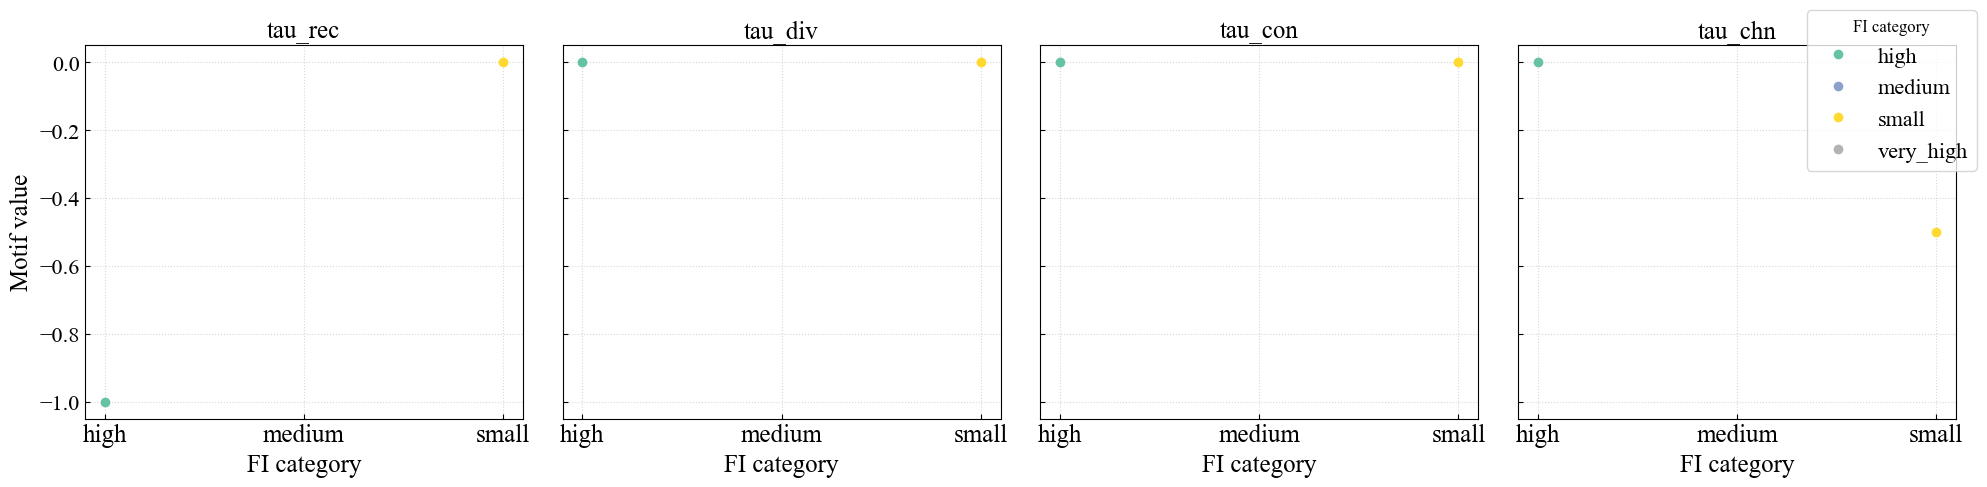

In [ ]:
# -------------------------------------------------
# Imports & helper functions
# -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def safe_divide(num, den):
    """Return num/den, but give np.nan wherever den == 0 (or nan)."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.where(den == 0, np.nan, num / den)

def motifs(w: np.ndarray, N: int):
    """
    Compute the four second‑order motifs (reciprocal, divergent,
    convergent, chain) on a square PSP matrix w of size N×N.
    """
    # centre, ignoring NaNs
    w = w - np.nanmean(w)
    # any remaining NaNs (e.g. diagonal after centring) become 0
    w = np.nan_to_num(w, nan=0.0)

    ww  = w @ w          # w·w
    wtw = w.T @ w        # wᵀ·w
    wwt = w @ w.T        # w·wᵀ

    sigma2 = np.trace(wwt) / N

    tau_rec = safe_divide(np.trace(ww),                sigma2 * N)

    pair_den = sigma2 * N * (N - 1)          # denominator common to the three pairwise motifs
    tau_div = safe_divide(np.sum(wwt) - np.trace(wwt), pair_den)
    tau_con = safe_divide(np.sum(wtw) - np.trace(wtw), pair_den)
    tau_chn = safe_divide(2 * (np.sum(ww) - np.trace(ww)), pair_den)

    return tau_rec, tau_div, tau_con, tau_chn


# -------------------------------------------------
# Initialise containers (the names you already used)
# -------------------------------------------------
empty_experiments = {}          # experiments whose full matrix is all NaN
non_empty_experiments = {}      # experiments that have at least one numeric entry
considered_experiments = []     # list of experiment IDs that survive the row‑count filter
motif_by_cat = []               # will become the final DataFrame


# -------------------------------------------------
# Load the *categorised* CSV and drop the “negative” FI‑slope
# -------------------------------------------------
df_temp = pd.read_csv("preprocessed_data_categorized.csv")
df_result = df_temp[df_temp['category'] != 'negative']      # ← correct filtering

# -------------------------------------------------
# Build a fast lookup: post‑cell ID → FI‑category
# -------------------------------------------------
post_category = (
    df_result[['post_cell_id', 'category']]
            .dropna()
            .drop_duplicates()
            .set_index('post_cell_id')['category']
            .to_dict()
)

# Only categories that actually appear in the *filtered* dataframe
all_categories = sorted(set(post_category.values()))
print("FI categories kept after filtering :", all_categories)


# -------------------------------------------------
# Keep only experiments that have at least 10 rows
# -------------------------------------------------
considered_experiments = [
    eid for eid in df_result['experiment_id'].unique()
    if (df_result['experiment_id'] == eid).sum() >= 10
]

n_experiments = len(considered_experiments)
max_abs_psp = 0.0
if n_experiments == 0:
    print("No experiments with sufficient data were found.")


# -------------------------------------------------
# MAIN LOOP – build full PSP matrix, split by FI‑category,
#                compute motifs for each (experiment, category) pair
# -------------------------------------------------
for experiment_id in considered_experiments:
    # ----- a) rows belonging to this experiment --------------------
    df_experiment = df_result[df_result['experiment_id'] == experiment_id]

    # ----- b) all cell IDs that appear as pre‑ or post‑cell -----
    all_cells = np.sort(
        pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel())
    )

    # ----- c) build the *full* square PSP matrix (post rows, pre cols) -----
    #   pivot is faster than a Python loop over rows
    psp_mat = df_experiment.pivot(
        index='post_cell_id',
        columns='pre_cell_id',
        values='psp_amplitude'
    )
    # make sure it is a complete square (missing rows/cols become NaN)
    psp_mat = psp_mat.reindex(index=all_cells, columns=all_cells)

    # ----- d) empty‑matrix test ------------------------------------
    if np.all(np.isnan(psp_mat.values)):
        empty_experiments[experiment_id] = (psp_mat, all_cells)
        continue

    # keep the full matrix for possible later visualisation
    non_empty_experiments[experiment_id] = (psp_mat, all_cells)

    # optional: update the global colour limit (used for the heat‑maps you already have)
    cur_max = np.nanmax(np.abs(psp_mat.values))
    if not np.isnan(cur_max):
        max_abs_psp = max(max_abs_psp, cur_max)

    # ----- e) split by FI category (postsynaptic) ----------
    # Which categories are present among the *post* cells of this experiment?
    cats_present = {post_category.get(c) for c in all_cells} - {None}

    for cat in cats_present:
        # ---- pick only the cells that belong to the current FI‑category
        cat_cells = [c for c in all_cells if post_category.get(c) == cat]

        # need at least 2 cells for the motif formulas (otherwise N‑1 = 0)
        if len(cat_cells) < 2:
            continue

        # ---- extract the square sub‑matrix that only contains those cells
        sub_mat = psp_mat.loc[cat_cells, cat_cells]

        # ---- compute motifs on the sub‑matrix
        N = sub_mat.shape[0]
        tau_rec, tau_div, tau_con, tau_chn = motifs(sub_mat.to_numpy(), N)

        # ---- store the result
        motif_by_cat.append({
            "experiment_id": experiment_id,
            "category"    : cat,
            "N_neurons"   : N,
            "tau_rec"     : tau_rec,
            "tau_div"     : tau_div,
            "tau_con"     : tau_con,
            "tau_chn"     : tau_chn
        })


# -------------------------------------------------
# Convert the list of dictionaries into a tidy DataFrame
# -------------------------------------------------
motif_cat_df = pd.DataFrame(motif_by_cat)

print("\n=== Motif statistics (experiment * FI-category) ===")
print(motif_cat_df.head())

# -------------------------------------------------
# Save the results (optional)
# -------------------------------------------------
motif_cat_df.to_csv("motifs_by_fi_category.csv", index=False)


# -------------------------------------------------
# Quick visual summary – mean ± SD of each motif per FI‑category
# -------------------------------------------------
taus = ['tau_rec', 'tau_div', 'tau_con', 'tau_chn']
cmap = plt.cm.Set2
# colour map that is the same for every panel
cat_colors = {cat: cmap(i / max(len(all_categories)-1, 1))
              for i, cat in enumerate(all_categories)}

fig, axes = plt.subplots(1, 4, figsize=(5*4, 5), sharey=True)

for ax, t in zip(axes, taus):
    for cat in all_categories:
        vals = motif_cat_df.loc[motif_cat_df['category'] == cat, t].dropna()
        if len(vals) == 0:
            continue
        mean = vals.mean()
        std  = vals.std()
        ax.errorbar(cat, mean, yerr=std,
                    fmt='o', capsize=4,
                    color=cat_colors[cat],
                    label=cat if ax is axes[0] else None)

    ax.set_title(t)
    ax.set_xlabel('FI category')
    ax.grid(True, ls=':', alpha=0.5)

axes[0].set_ylabel('Motif value')
# single legend for the whole figure
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cat_colors[cat],
                     label=cat, markersize=8)
           for cat in all_categories]
fig.legend(handles=handles, title='FI category', loc='upper right', ncol=1)

plt.tight_layout()
plt.show()


# Old

Experiment 600 has 12 data points.
Experiment 651 has 30 data points.
Experiment 688 has 12 data points.
Experiment 699 has 20 data points.
Experiment 700 has 12 data points.
Experiment 727 has 12 data points.
Experiment 729 has 30 data points.
Experiment 731 has 20 data points.
Experiment 732 has 12 data points.
Experiment 739 has 12 data points.
Experiment 771 has 12 data points.
Experiment 779 has 12 data points.
Experiment 780 has 12 data points.
Experiment 793 has 30 data points.
Experiment 862 has 12 data points.
Experiment 898 has 30 data points.
Experiment 900 has 30 data points.
Experiment 901 has 30 data points.
Experiment 934 has 30 data points.
Experiment 940 has 30 data points.
Experiment 1003 has 12 data points.
Experiment 1036 has 20 data points.
Experiment 1069 has 20 data points.
Experiment 1077 has 30 data points.
Experiment 1079 has 12 data points.
Experiment 1117 has 20 data points.
Experiment 1121 has 12 data points.
Experiment 1122 has 20 data points.
Experiment 1

C:\Users\Silje\AppData\Local\Temp\ipykernel_4916\3293241784.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


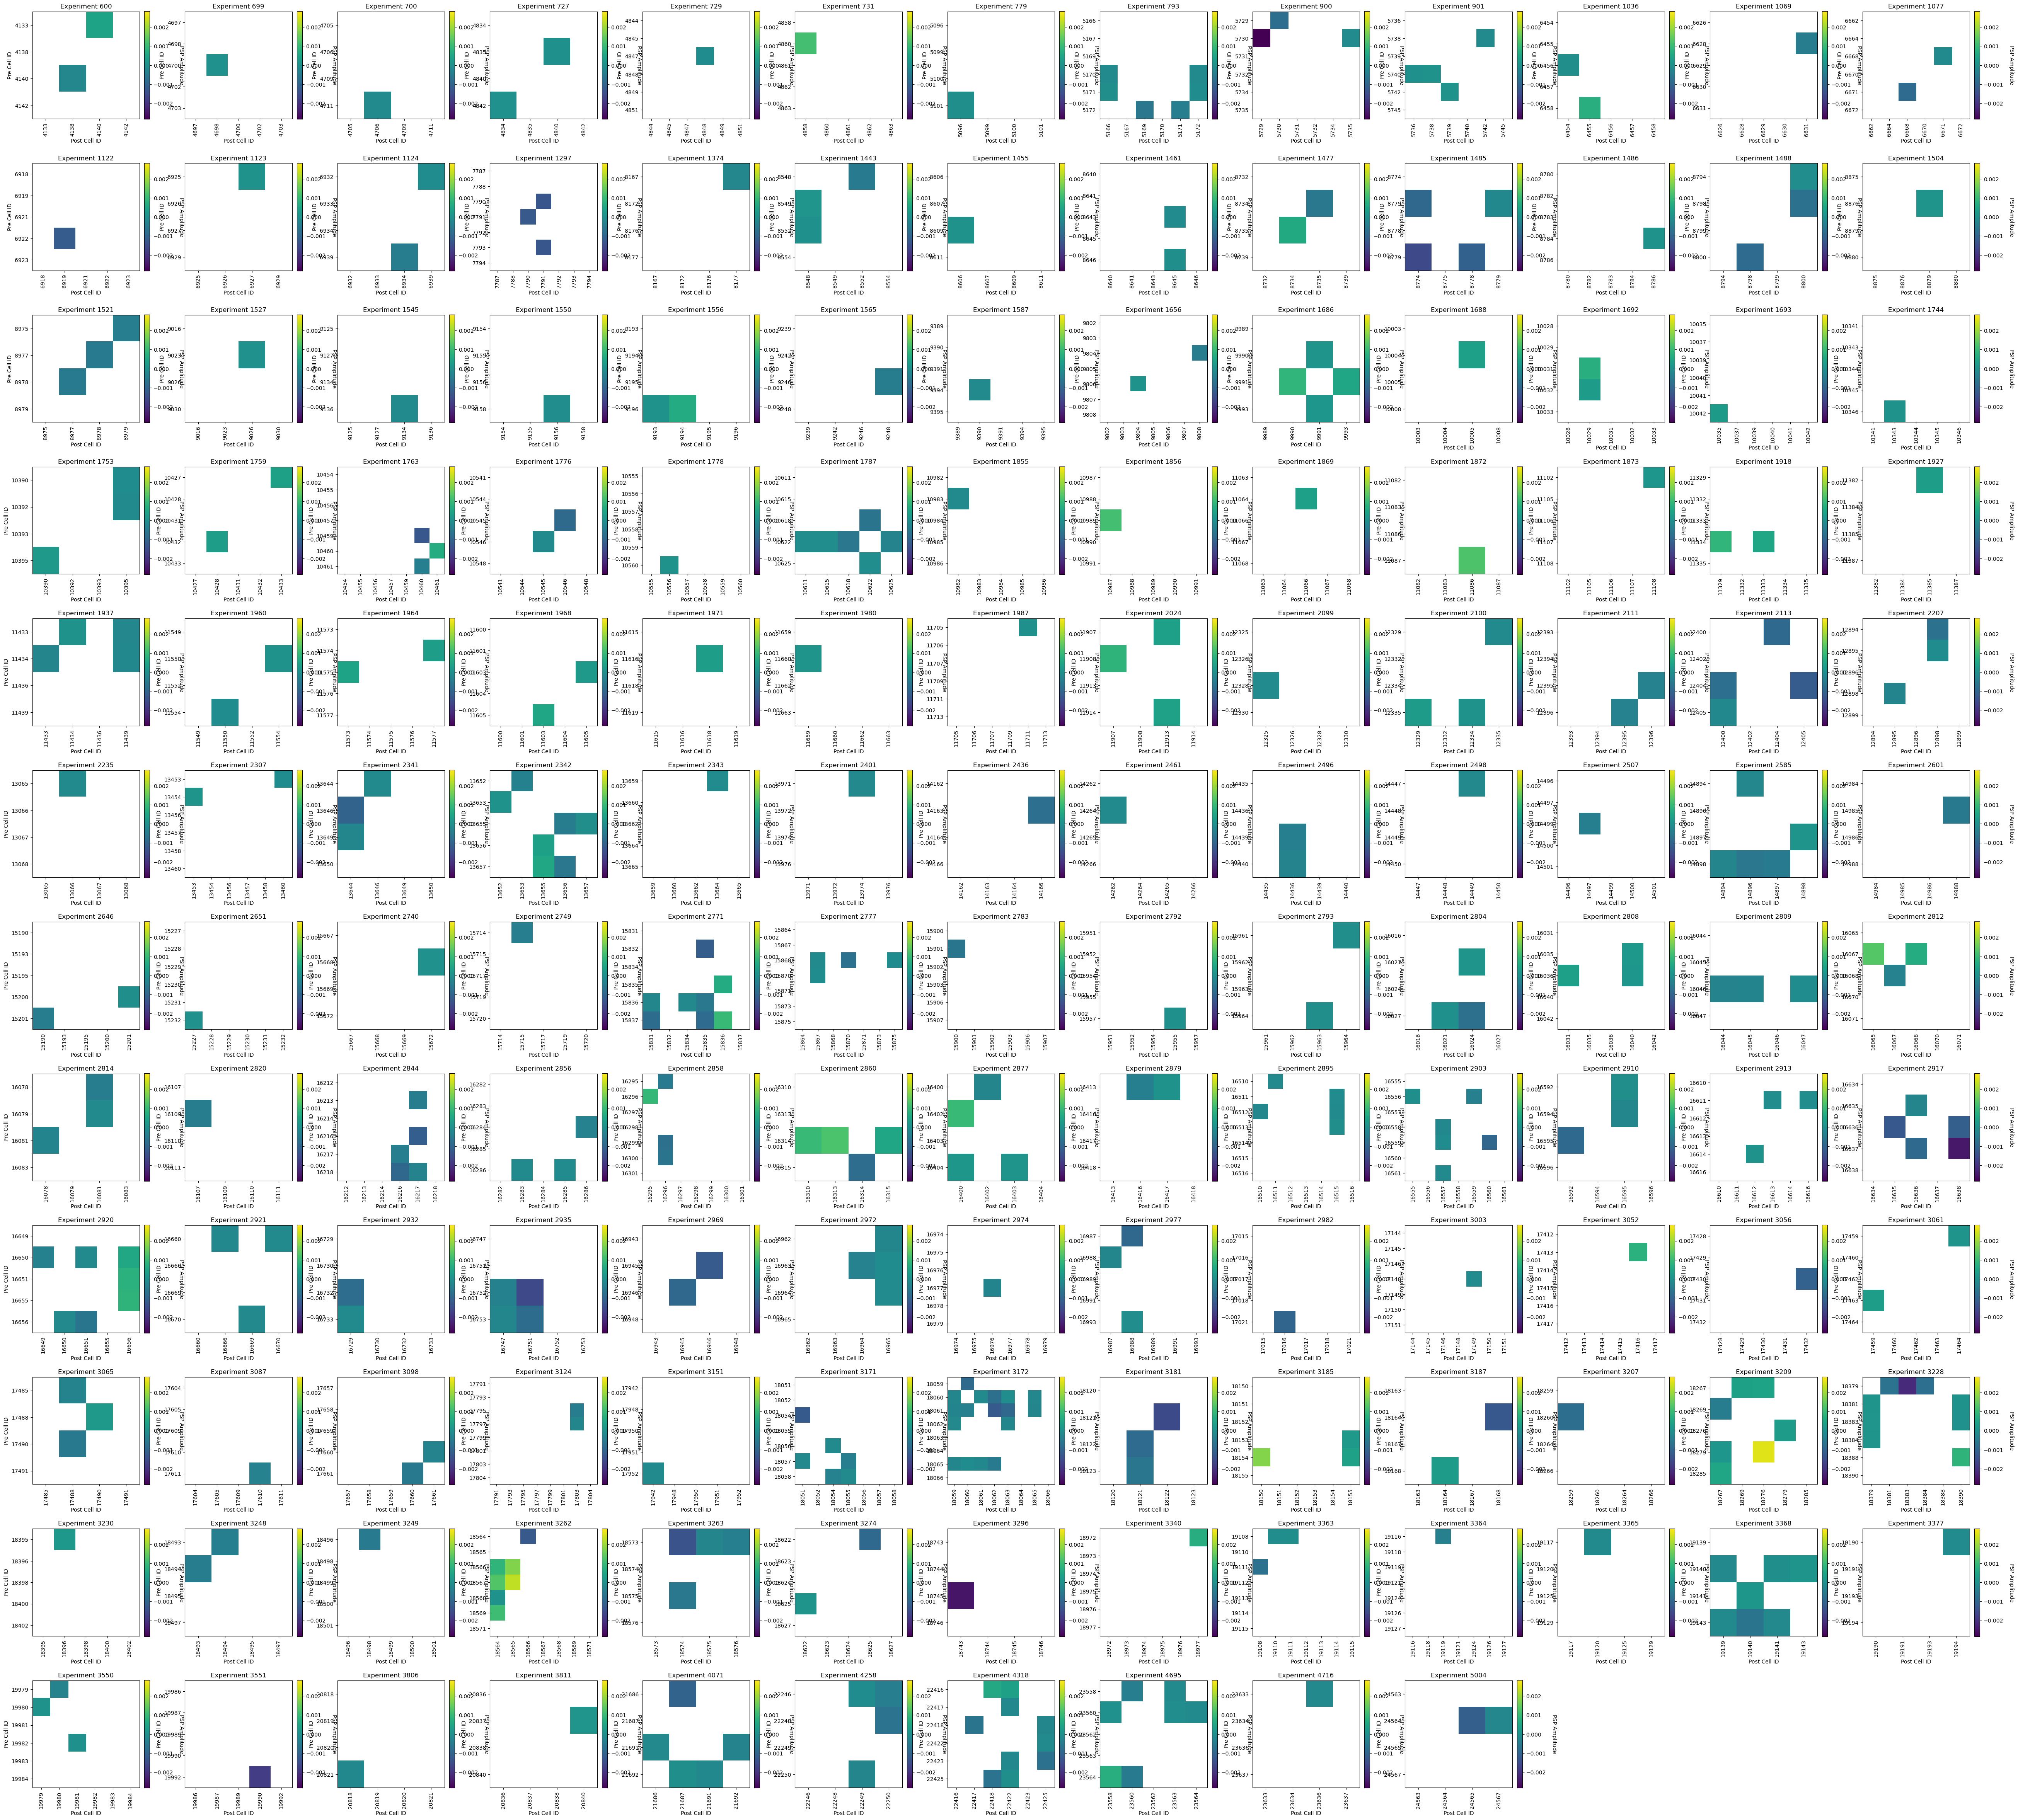

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Initialize containers
empty_experiments = {}  # those that had no synapses
non_empty_experiments = {}  # those that had something
considered_experiments = []  # List of considered experiments

# Load preprocessed data
df = pd.read_csv("preprocessed_data.csv")
df_result = df.copy()

# --------------------------------------------------

# Loop through all experiments and add to the list those with more than 10 data points
for experiment_id in df_result['experiment_id'].unique():
    df_experiment = df_result[df_result['experiment_id'] == experiment_id]
    
    if len(df_experiment) >= 10:
        considered_experiments.append(experiment_id)
        print(f'Experiment {experiment_id} has {len(df_experiment)} data points.')



# --------------------------------------------------

# Number of subplots based on number of data points
n_experiments = len(considered_experiments)



# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")
else:
    # --------------------------------------------------
    # Figure stuff


    # Calculate rows and columns for subplots
    # n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    # n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    
    # # Determine figure size based on number of subplots
    # fig = plt.figure(figsize=(5 * n_cols, 5 * n_rows))

    # # Use gridspec to manage colorbar spacing
    # gs = fig.add_gridspec(n_rows, n_cols, width_ratios=[1] * n_cols, height_ratios=[1] * n_rows)

    # # Create subplot axes
    # axes = [fig.add_subplot(gs[i // n_cols, i % n_cols]) for i in range(n_experiments)]

    # --------------------------------------------------
    
    # Determine maximum absolute PSP value for a common range across all subplots
    # max_abs_psp = -np.inf  # unsafe
    max_abs_psp = 0.0   # start with a neutral zero

    # --------------------------------------------------

for experiment_id in considered_experiments:  # Loop through only experiments with > k data points 

    df_experiment = df_result[df_result['experiment_id'] == experiment_id]   # Get ID
    all_cells = np.sort(pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel()))  # Get cells
    df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)  # Initialize dataframe of size (all_cells, all_cells)

    # --------------------------------------------------

    # PSP MATRIX

    for _, row in df_experiment.iterrows():  # Fill dataframe with PSP amplitude values for the synapses between pre- and postsynaptic cell
        pre_cell = row['pre_cell_id']
        post_cell = row['post_cell_id']
        psp_value = row['psp_amplitude']
        df_psp_matrix.loc[pre_cell, post_cell] = psp_value


    # Transpose matrix to get (post, pre)
    df_psp_matrix = df_psp_matrix.T

    # psp_matrix_numpy = df_psp_matrix.values  # get in numpy values, but not anymore the preferred way
    psp_matrix_numpy = df_psp_matrix.to_numpy()  # get in numpy values, becomes shape ()

    # --------------------------------------------------

    # If empty, save in the empty list. Do not plot
    if np.all(np.isnan(df_psp_matrix.values)):
        empty_experiments[experiment_id] = (df_psp_matrix, df_psp_matrix.index.values)
        continue

    # If not empty, save in other list
    non_empty_experiments[experiment_id] = (df_psp_matrix, df_psp_matrix.index.values)

    # --------------------------------------------------

    # Update global color limit
    # Unsafe part:
    # max_abs_psp = max(max_abs_psp, np.nanmax(np.abs(psp_matrix_numpy)))  # Update maximum value
    # An alternative is:
    cur_max = np.nanmax(np.abs(psp_matrix_numpy))
    if not np.isnan(cur_max):
        max_abs_psp = max(max_abs_psp, cur_max)  # now max_abs_psp stays at 0 if there is no numeric data, which makes vmin=vmax=0 a valid, blank point


# # --------------------------------------------------


# # Loop through each considered experiment
# for i, experiment_id in enumerate(considered_experiments):
#     df_experiment = df_result[df_result['experiment_id'] == experiment_id]
    
#     # Generate PSP matrix for the experiment
#     all_cells = np.sort(pd.unique(df_experiment[['pre_cell_id', 'post_cell_id']].values.ravel()))
#     df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)

#     for _, row in df_experiment.iterrows():
#         pre_cell = row['pre_cell_id']
#         post_cell = row['post_cell_id']
#         psp_value = row['psp_amplitude']
#         df_psp_matrix.loc[pre_cell, post_cell] = psp_value

#     psp_matrix_numpy = df_psp_matrix.values


# -------------------------------------------------
# Layout of sub‑plots (grid based on number of *plottable* experiments)
n_exps = len(non_empty_experiments)
n_cols = int(np.ceil(np.sqrt(n_exps)))
n_rows = int(np.ceil(n_exps / n_cols))

fig = plt.figure(figsize=(5 * n_cols, 5 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, wspace=0.3, hspace=0.3)

axes = [fig.add_subplot(gs[i // n_cols, i % n_cols]) for i in range(n_exps)]

# -------------------------------------------------

# Plot each stored matrix

for i, (experiment_id, (psp_mat, cells)) in enumerate(non_empty_experiments.items()):
    # Create a mask for NaN values
    masked_psp_matrix = np.ma.masked_invalid(psp_mat.to_numpy())

    # Plot PSP matrix in corresponding subplot
    im = axes[i].imshow(masked_psp_matrix, cmap='viridis', interpolation='none', vmin=-max_abs_psp, vmax=max_abs_psp)
    axes[i].set_title(f'Experiment {experiment_id}')
    
    # Set tick labels with pre_cell_id and post_cell_id values
    axes[i].set_xticks(np.arange(len(cells)))
    axes[i].set_yticks(np.arange(len(cells)))
    axes[i].set_xticklabels(cells, rotation=90)
    axes[i].set_yticklabels(cells)
    axes[i].set_xlabel('Post Cell ID')
    axes[i].set_ylabel('Pre Cell ID')

    # Create colorbar with same size as subplot
    cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
    # Rotate colorbar title 180 degrees
    cbar.set_label('PSP Amplitude', rotation=270, labelpad=20)

# Remove empty axes if there are fewer experiments than subplots
for j in range(n_experiments, len(axes)):
    axes[j].axis('off')


# Adjust subplots
plt.tight_layout()
# plt.savefig('psp_matrix.png')
plt.show()

